# **Predicting the Probability of Diabetes Diagnosis Using Machine Learning**

#### **Objective:** To develop and evaluate machine learning models for predicting the probability of diabetes diagnosis among patients using demographic, behavioral, and clinical health indicators.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
from plotnine import *
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix

## **Data Cleaning**

In [2]:
# Load the csv file
diabetes = pd.read_csv("diabetes_prediction_dataset.csv")

# Show the first 5 rows
diabetes.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
# Show the last 5 rows
diabetes.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [4]:
# Check the dataset information
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


##### *From the information above, there were no missing values and the data were in the appropriate datatype*

In [5]:
# Check for duplicates
diabetes.duplicated().sum()

np.int64(3854)

In [6]:
# Drop the duplicates
diabetes_1 = diabetes.drop_duplicates()
diabetes_1.duplicated().sum()

np.int64(0)

In [7]:
# Let's check the data left after removing duplicates
diabetes_1.shape

(96146, 9)

In [8]:
# Check the summary of the numerical variables
diabetes_1.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [9]:
# Check the skewness of the data
diabetes_1.skew(numeric_only = True)

age                   -0.062445
hypertension           3.157676
heart_disease          4.642359
bmi                    1.023751
HbA1c_level           -0.054463
blood_glucose_level    0.836489
diabetes               2.903845
dtype: float64

In [10]:
# Check the unique value in the variable
for i in diabetes_1:
    print(f'{i} ---> {diabetes_1[i].unique()}')

gender ---> ['Female' 'Male' 'Other']
age ---> [80.   54.   28.   36.   76.   20.   44.   79.   42.   32.   53.   78.
 67.   15.   37.   40.    5.   69.   72.    4.   30.   45.   43.   50.
 41.   26.   34.   73.   77.   66.   29.   60.   38.    3.   57.   74.
 19.   46.   21.   59.   27.   13.   56.    2.    7.   11.    6.   55.
  9.   62.   47.   12.   68.   75.   22.   58.   18.   24.   17.   25.
  0.08 33.   16.   61.   31.    8.   49.   39.   65.   14.   70.    0.56
 48.   51.   71.    0.88 64.   63.   52.    0.16 10.   35.   23.    0.64
  1.16  1.64  0.72  1.88  1.32  0.8   1.24  1.    1.8   0.48  1.56  1.08
  0.24  1.4   0.4   0.32  1.72  1.48]
hypertension ---> [0 1]
heart_disease ---> [1 0]
smoking_history ---> ['never' 'No Info' 'current' 'former' 'ever' 'not current']
bmi ---> [25.19 27.32 23.45 ... 59.42 44.39 60.52]
HbA1c_level ---> [6.6 5.7 5.  4.8 6.5 6.1 6.  5.8 3.5 6.2 4.  4.5 9.  7.  8.8 8.2 7.5 6.8]
blood_glucose_level ---> [140  80 158 155  85 200 145 100 130 160 126

In [11]:
# Oops! the gender variable has unknown values. Let's filter it out
Other = diabetes_1[diabetes_1["gender"] == "Other"]
Other.gender.value_counts()

gender
Other    18
Name: count, dtype: int64

In [12]:
# Let's drop the "Other" in gender variable
diabetes_1.drop(diabetes_1[diabetes_1["gender"] == "Other"].index, inplace=True)
diabetes_1.shape

C:\Users\User\AppData\Local\Temp\ipykernel_13516\2035253115.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


(96128, 9)

## **Exploratory Data Analysis**

#### **Distribution of Diabetes Diagnosis Among Patients**

In [13]:
# Column names
diabetes_1.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [14]:
# Count the diabetic and non-diabetic patients
dia_diag = diabetes_1["diabetes"].value_counts(normalize=True) * 100
dia_diag

diabetes
0    91.176348
1     8.823652
Name: proportion, dtype: float64

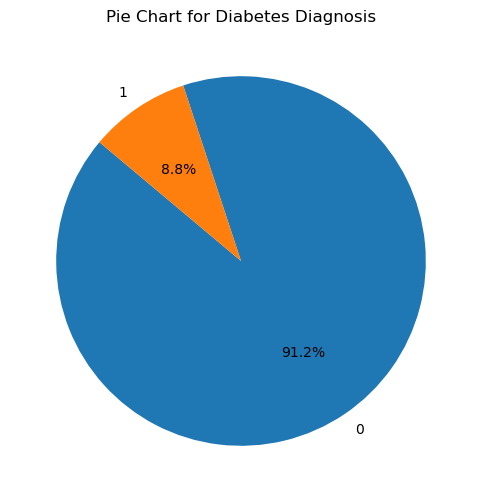

In [15]:
# Show the diabetes distribution of the data using pie plot

plt.figure(figsize = (10,6))
diabetes_1["diabetes"].value_counts().plot(kind="pie", autopct = "%1.1f%%", startangle = 140)
plt.title("Pie Chart for Diabetes Diagnosis")
plt.ylabel("")
plt.show()

#### **Interpretation**: Only 8.8% of the population has diabetes, others are non-diabetics. This distribution also reflect the class imbalance in the dataset

#### **Distribution of Gender**

In [16]:
# Count the number of males and females
gender = diabetes_1["gender"].value_counts()
gender

gender
Female    56161
Male      39967
Name: count, dtype: int64

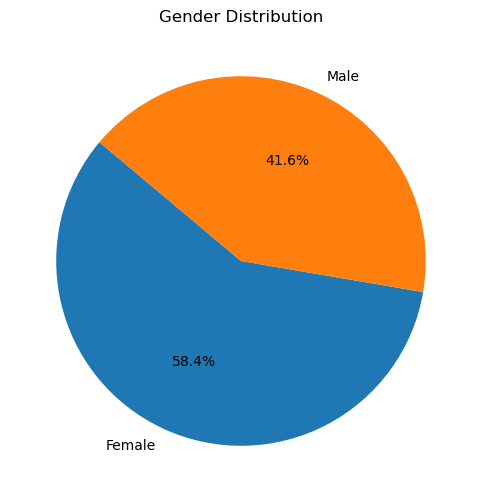

In [17]:
# Show the gender distribution of the data using pie plot

plt.figure(figsize = (10,6))
diabetes_1["gender"].value_counts().plot(kind="pie", autopct = "%1.1f%%", startangle = 140)
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

#### **Interpretation**: The chart reveals that female (58.4%) dominate the population.

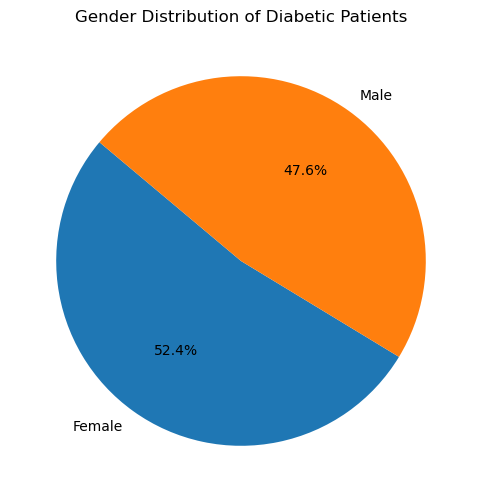

In [18]:
# Let's check the gender distribution of diabetic patients
gender_diabetes = diabetes_1[diabetes_1["diabetes"] == 1]
gender_diabetes["gender"].value_counts()

plt.figure(figsize = (10,6))
gender_diabetes["gender"].value_counts().plot(kind="pie", autopct = "%1.1f%%", startangle = 140)
plt.title("Gender Distribution of Diabetic Patients")
plt.ylabel("")
plt.show()

#### **Interpretation**: The pie chart shows that females are more diabetic compared to male. Does it mean female has the higher tendency of getting diabetes than male?

#### **Relationship between Age and Diabetes**

In [19]:
# Let's divide the age into group

bins = [0, 12, 18, 44, 64, float('inf')]
labels = ["Childhood", "Adolescence", "Young Adulthood", "Middle Age", "Older Adulthood"]
diabetes_1["age_group"] = pd.cut(
    diabetes_1["age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
diabetes_1.head()

C:\Users\User\AppData\Local\Temp\ipykernel_13516\84987522.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_group
0,Female,80.0,0,1,never,25.19,6.6,140,0,Older Adulthood
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,Middle Age
2,Male,28.0,0,0,never,27.32,5.7,158,0,Young Adulthood
3,Female,36.0,0,0,current,23.45,5.0,155,0,Young Adulthood
4,Male,76.0,1,1,current,20.14,4.8,155,0,Older Adulthood


In [20]:
# Let's check the age group with highest diabetes
diab = diabetes_1[diabetes_1["diabetes"] == 1]
diab = diab[["age_group", "gender"]].groupby("age_group").value_counts().reset_index()
diab

C:\Users\User\AppData\Local\Temp\ipykernel_13516\74547441.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,age_group,gender,count
0,Childhood,Female,22
1,Childhood,Male,14
2,Adolescence,Female,30
3,Adolescence,Male,26
4,Young Adulthood,Female,566
5,Young Adulthood,Male,448
6,Middle Age,Female,1824
7,Middle Age,Male,1767
8,Older Adulthood,Female,2005
9,Older Adulthood,Male,1780


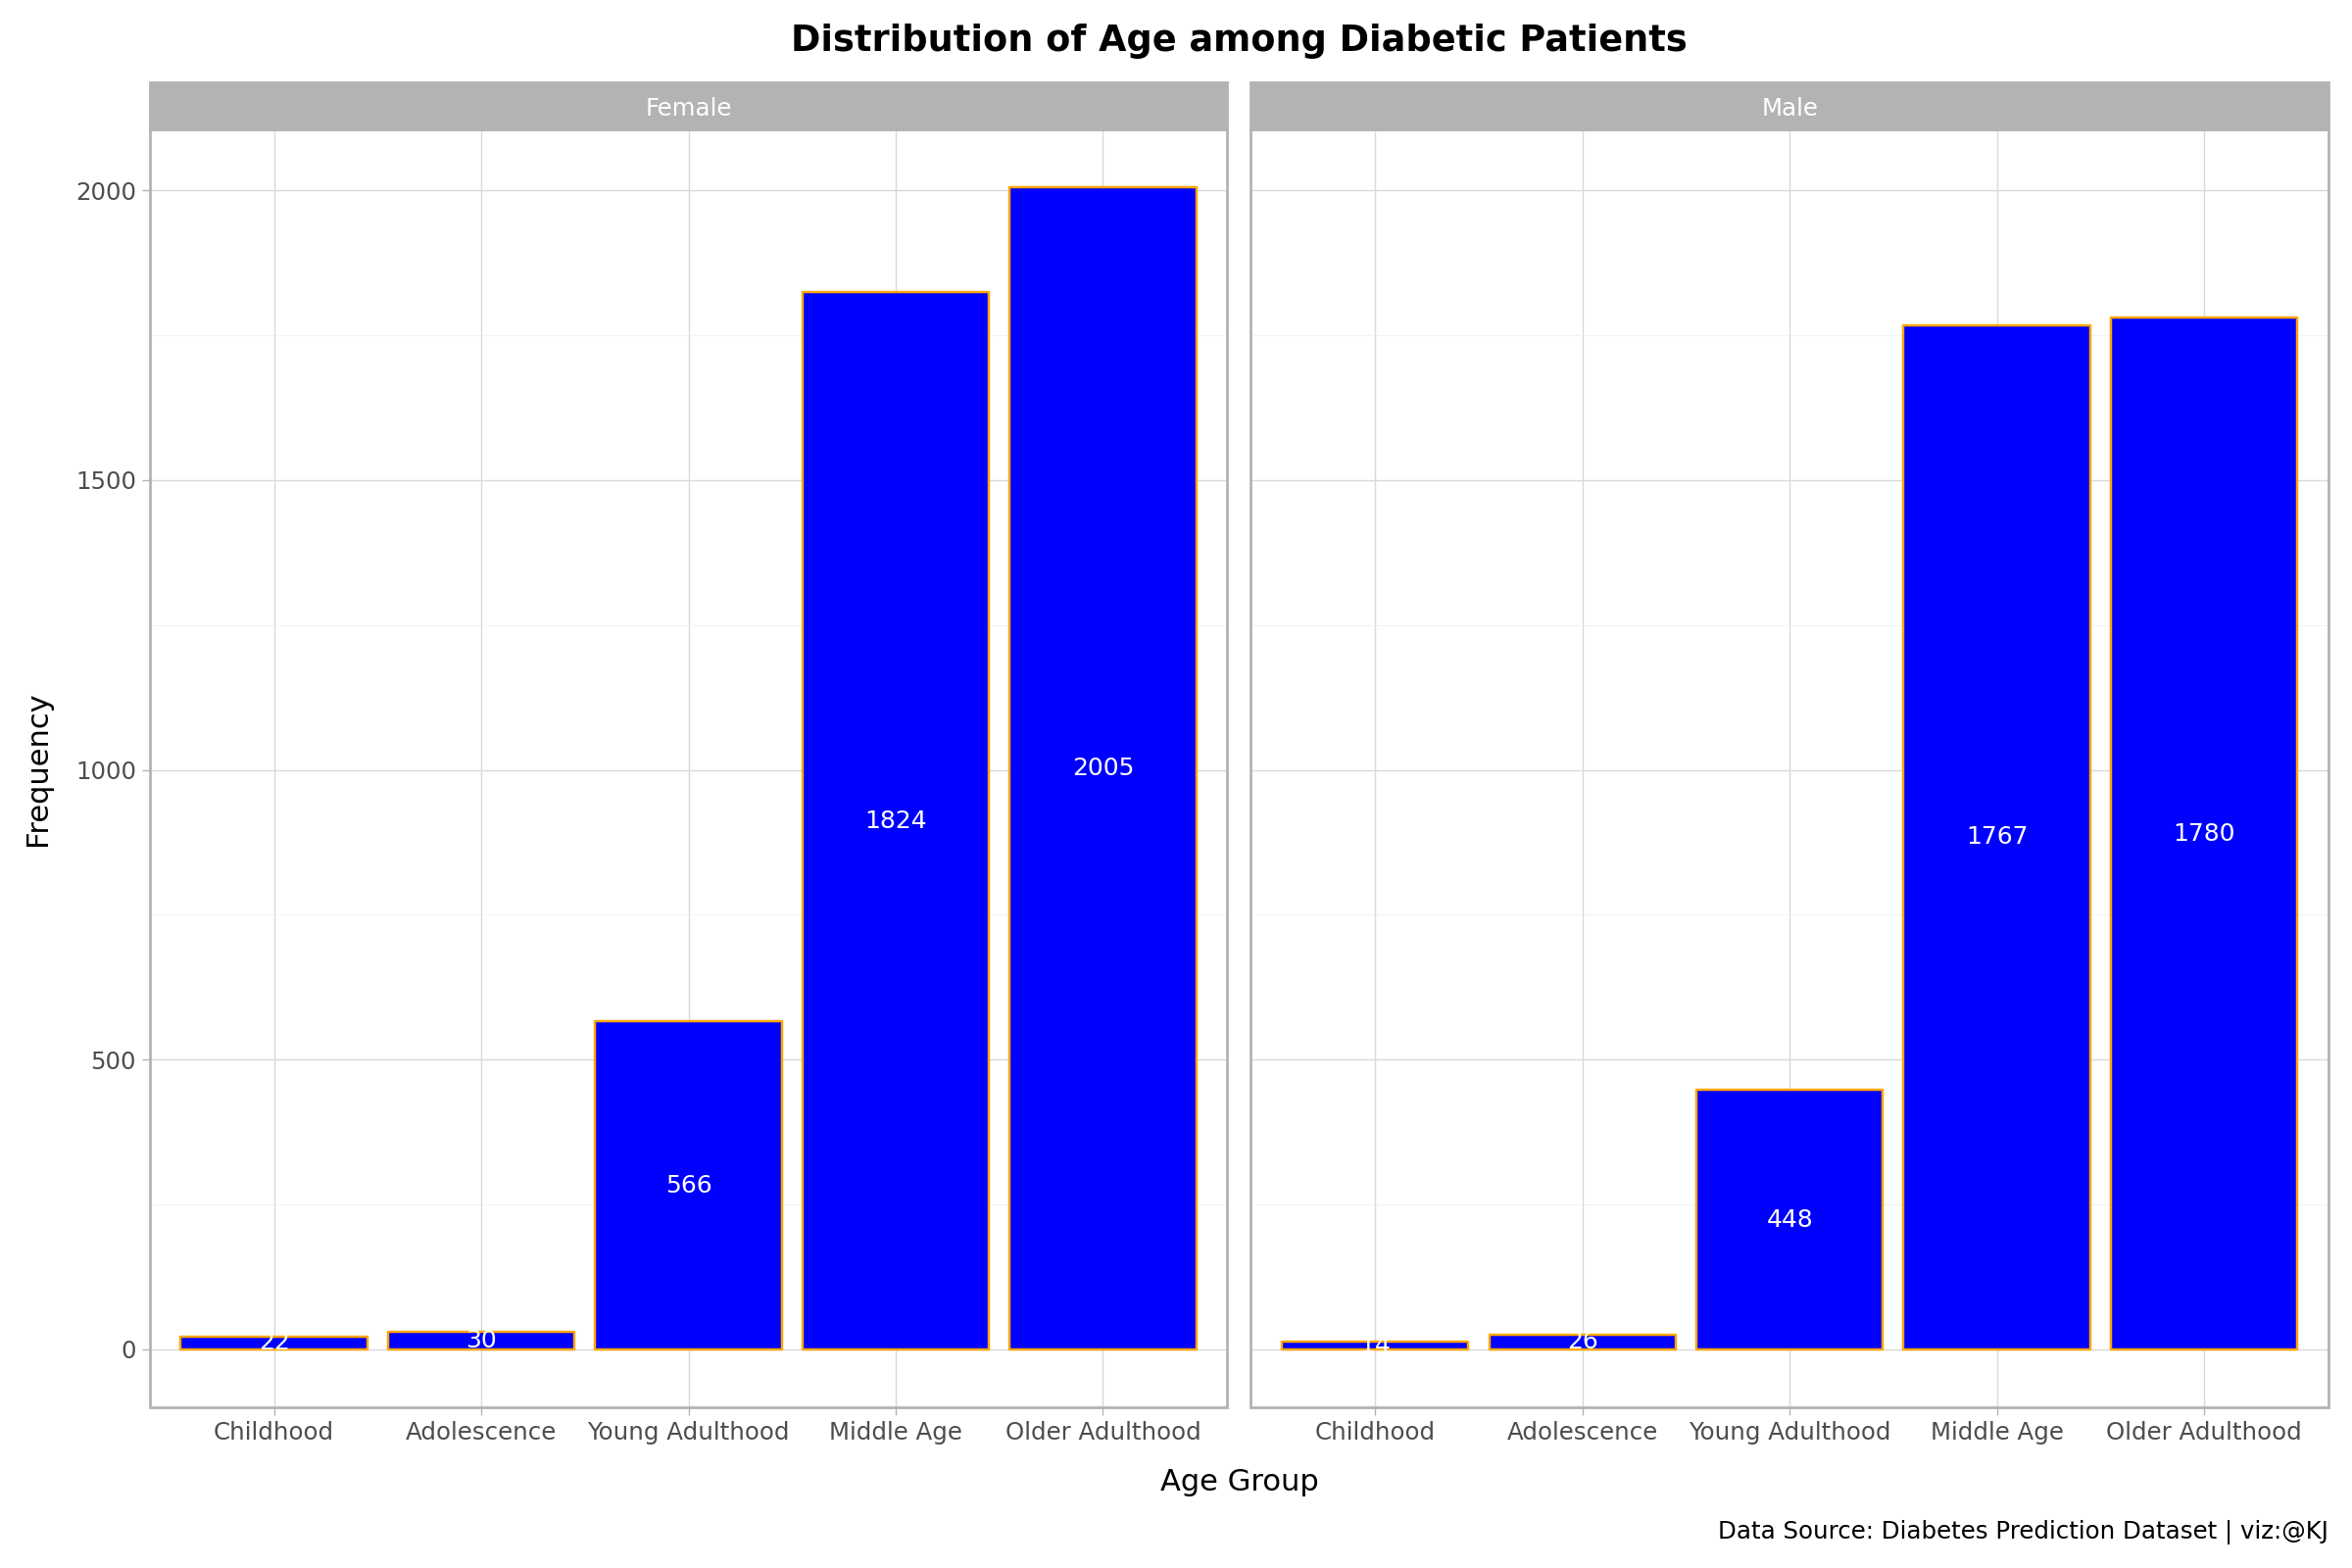

In [21]:
# Visualize the age group of the population
(ggplot(diab, aes("age_group", "count"))
+ geom_col(fill="blue", color="orange")
+ facet_wrap("gender")
+ geom_text(aes(label="count"), position = position_stack(vjust = 0.5), size=9, color="white")
+ labs(x = "Age Group", 
       y = "Frequency", 
       title = "Distribution of Age among Diabetic Patients", 
       caption = "Data Source: Diabetes Prediction Dataset | viz:@KJ")
+ theme_light()
+ theme(figure_size=(12,8),
         plot_title = element_text(weight = "bold"))
)

#### **Interpretation**: In the female age group distribution, older adulthood is the highest, followed by middle age and young adulthood. In males, both older adulthood and middle age have similar distribution, followed by young adulthood. In conclusion, females dominate each age group, meaning they are more diabetic than the males across each age group.

#### **Relationship between Hypertension and Diabetes**

In [22]:
# Aggregate data: Subset hypertension and diabetes variables from the dataset
hyp_dia = (diabetes_1[["hypertension", "diabetes"]].groupby("hypertension").value_counts(normalize=True)*100).round(1).reset_index()
hyp_dia["hypertension"] = hyp_dia["hypertension"].replace([0, 1], ["Non-hypertensive", "Hypertensive"])
hyp_dia["diabetes"] = hyp_dia["diabetes"].replace([0, 1], ["Non-diabetic", "Diabetic"])
hyp_dia

,hypertension,diabetes,proportion
0,Non-hypertensive,Non-diabetic,92.8
1,Non-hypertensive,Diabetic,7.2
2,Hypertensive,Non-diabetic,72.0
3,Hypertensive,Diabetic,28.0


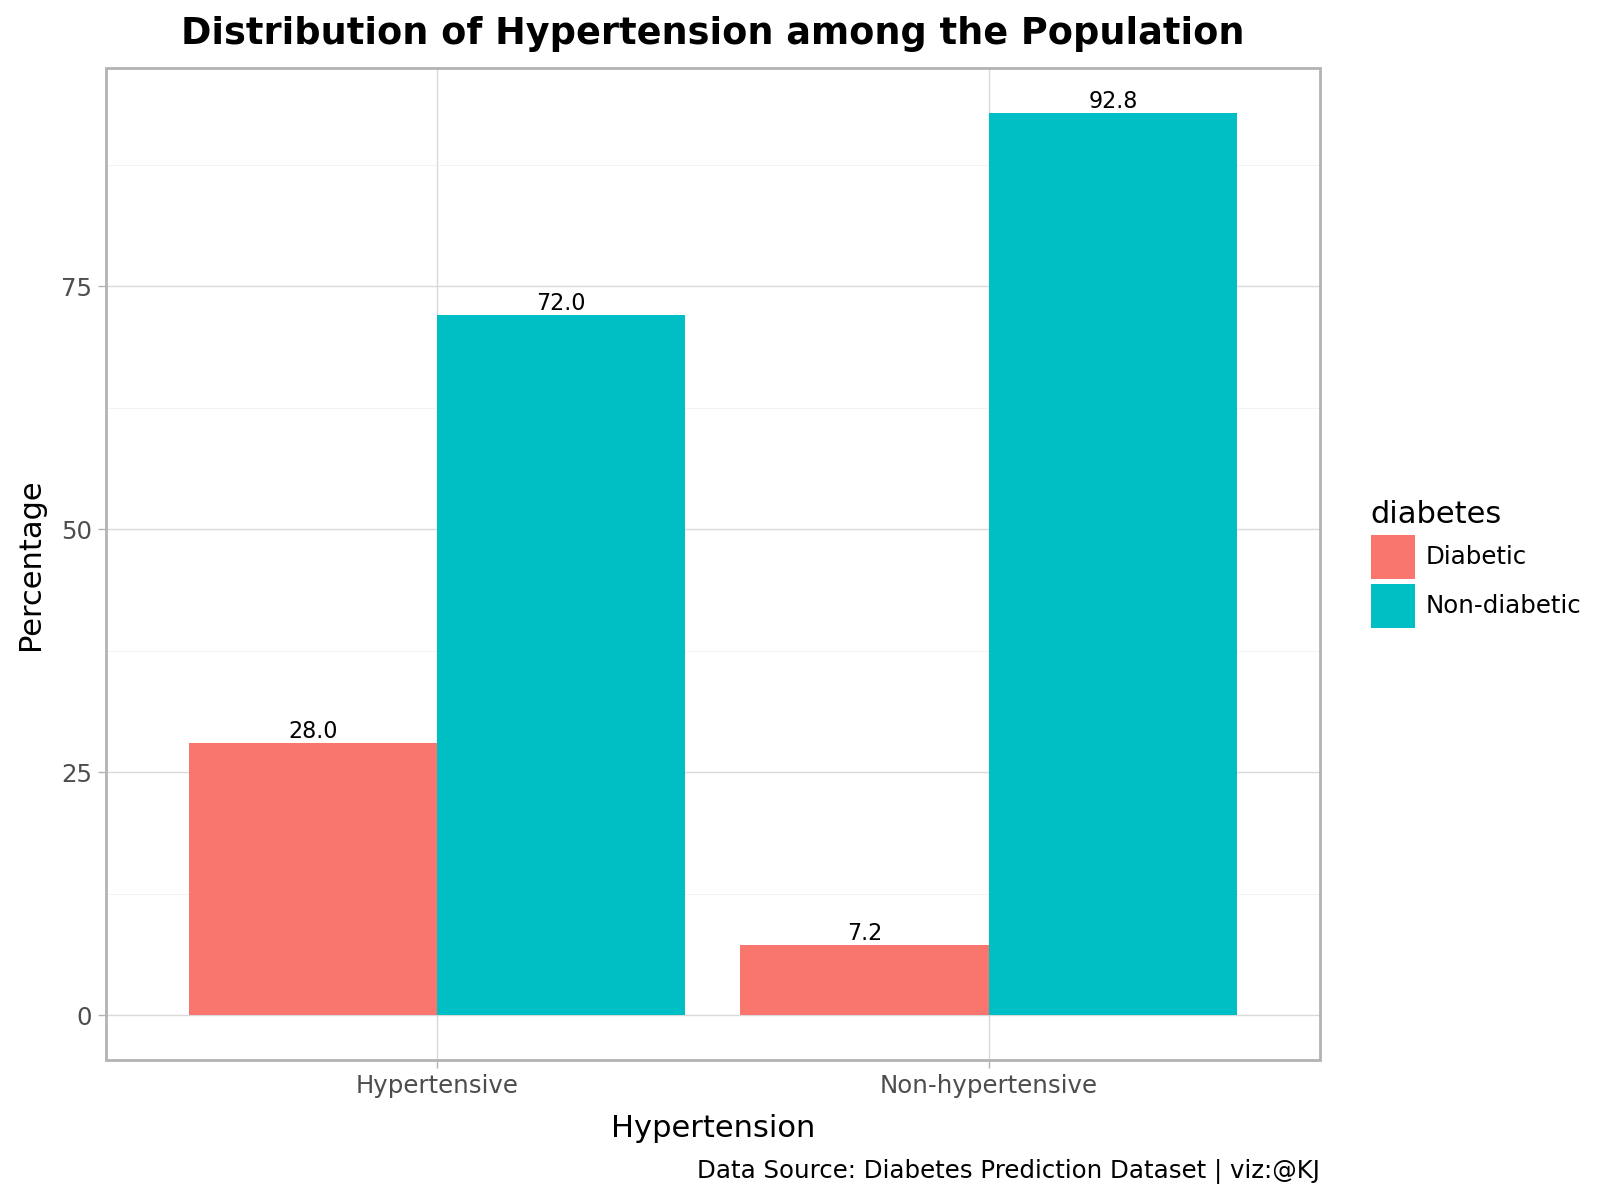

In [23]:
# Let's visualize
(ggplot(hyp_dia, aes("hypertension", "proportion", fill="diabetes"))
+ geom_col(position="dodge")
+ geom_text(
    aes(label="proportion"),
    position=position_dodge(width=0.9),
    va='bottom',
    size=8,
    color='black'
)
+ labs(x = "Hypertension", 
       y = "Percentage", 
       title = "Distribution of Hypertension among the Population", 
       caption = "Data Source: Diabetes Prediction Dataset | viz:@KJ")
+ theme_light()
+ theme(figure_size=(8,6),
         plot_title = element_text(weight = "bold"))
)

#### **Interpretation**: Among individuals with hypertension, **28%** were diabetic while **72%** were non-diabetic. In contrast, only **7%** of individuals without hypertension were diabetic, compared to **93%** who were non-diabetic. This indicates that diabetes was considerably more prevalent among hypertensive individuals, suggesting a positive association between hypertension and diabetes diagnosis.

#### **Relationship between Heart Disease and Diabetes**

In [24]:
# Aggregate data: Subset heart disease and diabetes variables from the dataset
heart_dia = (diabetes_1[["heart_disease", "diabetes"]].groupby("heart_disease").value_counts(normalize=True)*100).round(1).reset_index()
heart_dia["heart_disease"] = heart_dia["heart_disease"].replace([0, 1], ["No", "Yes"])
heart_dia["diabetes"] = heart_dia["diabetes"].replace([0, 1], ["Non-diabetic", "Diabetic"])
heart_dia

,heart_disease,diabetes,proportion
0,No,Non-diabetic,92.2
1,No,Diabetic,7.8
2,Yes,Non-diabetic,67.7
3,Yes,Diabetic,32.3


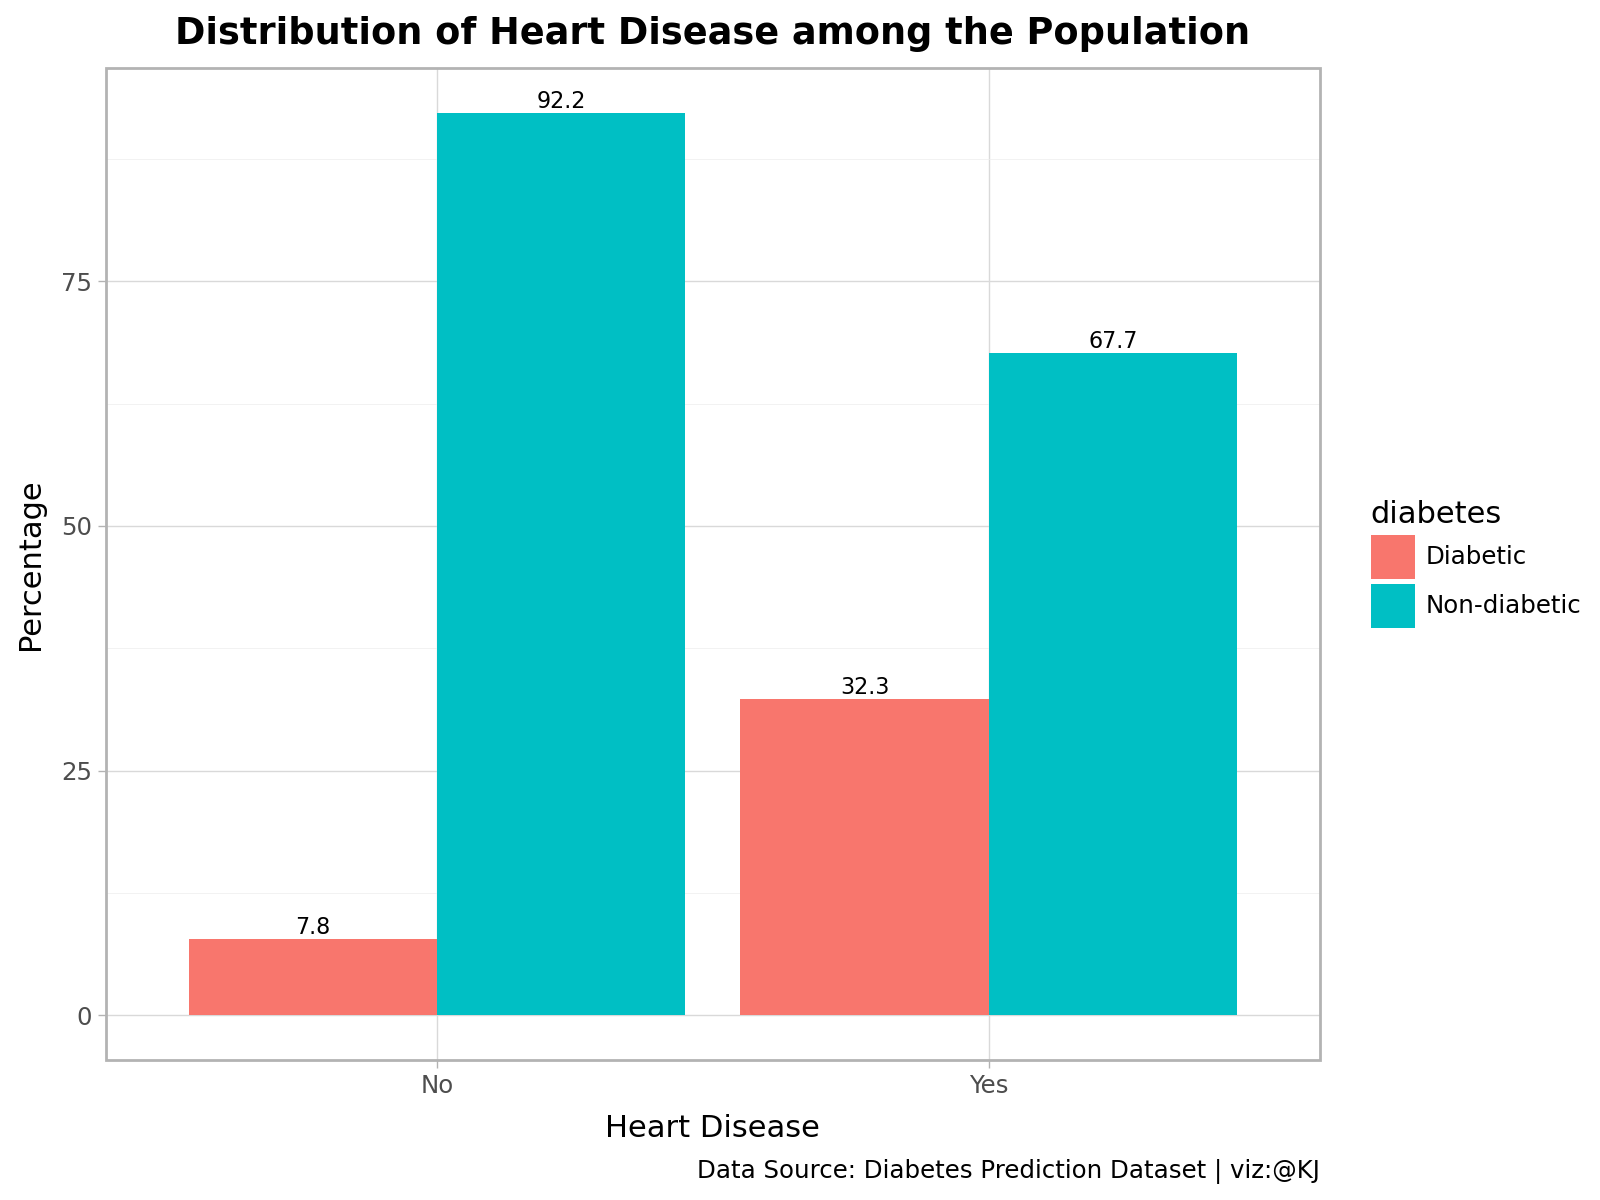

In [25]:
# Let's visualize
(ggplot(heart_dia, aes("heart_disease", "proportion", fill="diabetes"))
+ geom_col(position="dodge")
+ geom_text(
    aes(label="proportion"),
    position=position_dodge(width=0.9),
    va='bottom',
    size=8,
    color='black'
)
+ labs(x = "Heart Disease", 
       y = "Percentage", 
       title = "Distribution of Heart Disease among the Population", 
       caption = "Data Source: Diabetes Prediction Dataset | viz:@KJ")
+ theme_light()
+ theme(figure_size=(8,6),
         plot_title = element_text(weight = "bold"))
)

#### **Interpretation**: Among individuals with heart disease, **32%** were diabetic while **68%** were non-diabetic. In contrast, only **8%** of individuals without heart disease were diabetic, compared to **92%** who were non-diabetic. This indicates that diabetes was considerably more prevalent among individuals with heart problem, suggesting a positive association between heart disease and diabetes diagnosis.

#### **Relationship between Smoking and Diabetes**

In [26]:
diabetes_1.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'age_group'],
      dtype='object')

In [27]:
# Aggregate data: Subset smoking history, gender, and diabetes variables from the dataset
smoke_dia = diabetes_1[["smoking_history", "diabetes", "gender"]].groupby("smoking_history").value_counts().reset_index()
smoke_dia["total"] = smoke_dia.groupby("smoking_history")["count"].transform("sum")
smoke_dia["percentage"] = (smoke_dia["count"]/smoke_dia["total"] *100).round(1)
smoke_dia1 = smoke_dia[smoke_dia["diabetes"] == 1]
smoke_dia1

,smoking_history,diabetes,gender,count,total,percentage
2,No Info,1,Female,747,32881,2.3
3,No Info,1,Male,698,32881,2.1
6,current,1,Male,497,9197,5.4
7,current,1,Female,451,9197,4.9
10,ever,1,Male,261,3997,6.5
11,ever,1,Female,211,3997,5.3
14,former,1,Male,941,9299,10.1
15,former,1,Female,649,9299,7.0
18,never,1,Female,1995,34395,5.8
19,never,1,Male,1342,34395,3.9


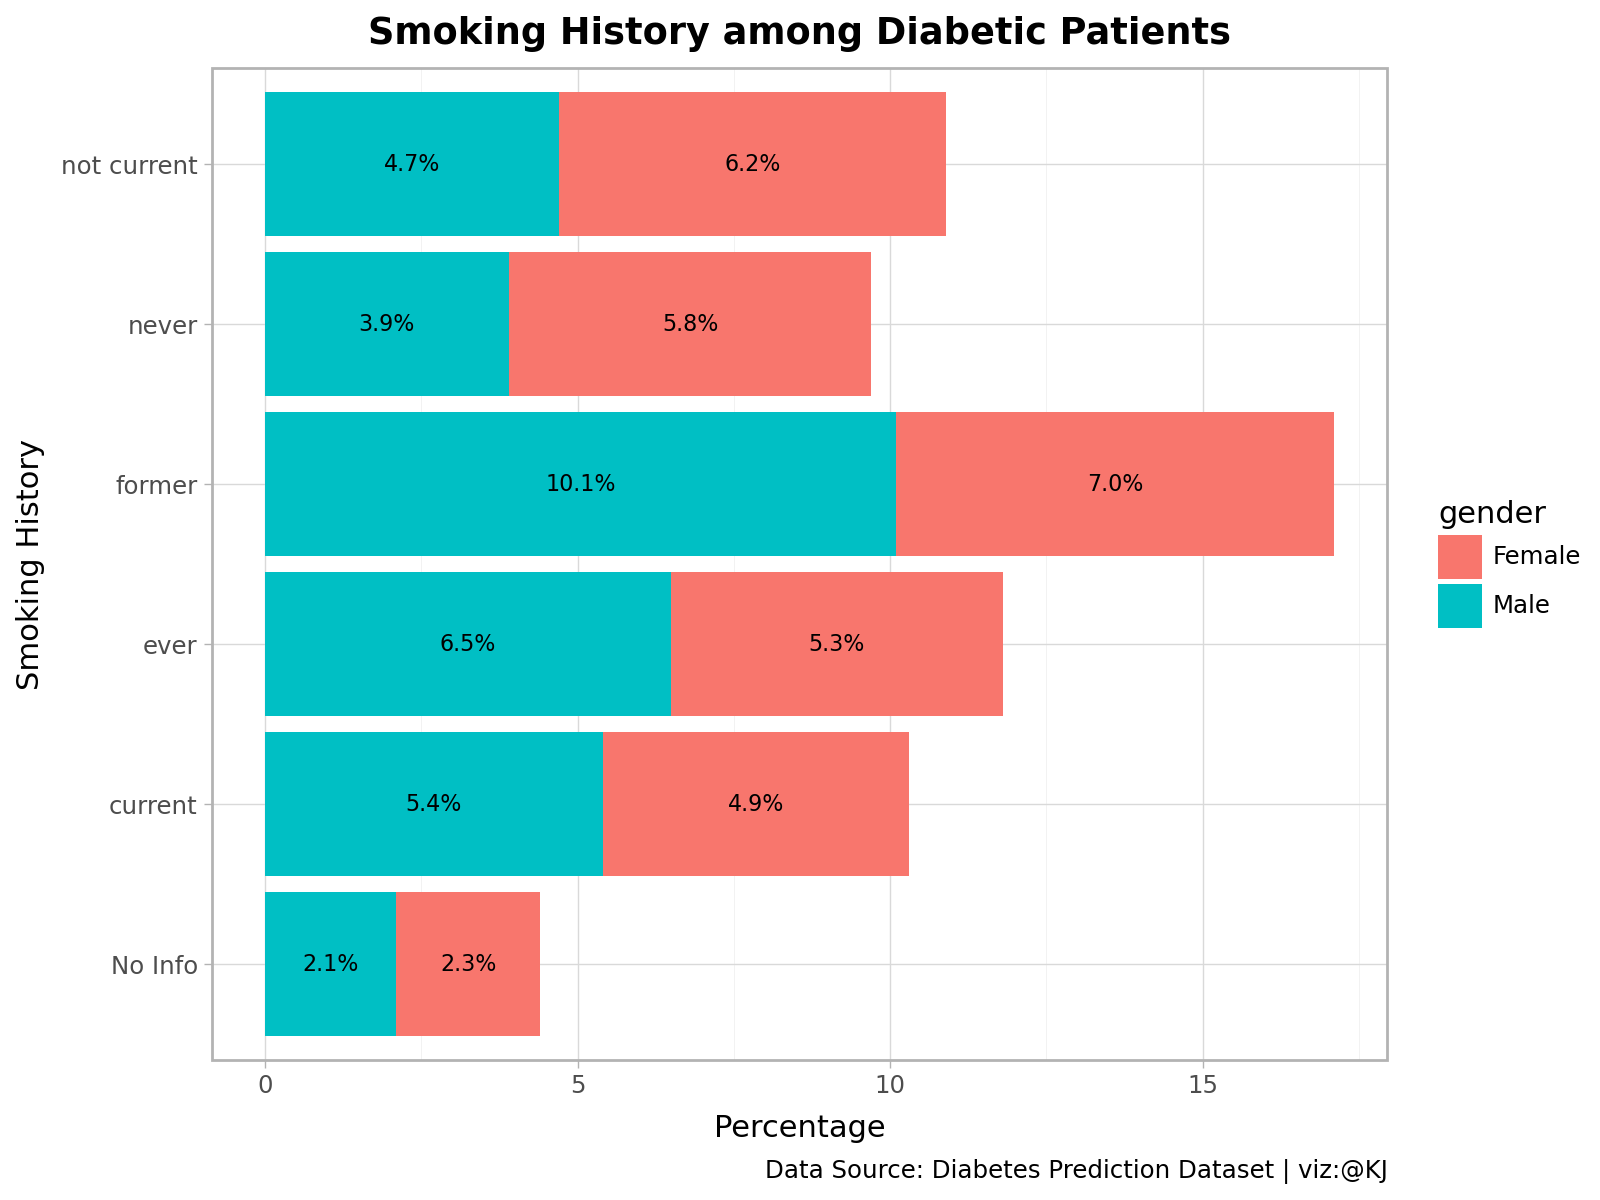

In [28]:
# Let's visualize
(ggplot(smoke_dia1, aes("smoking_history", "percentage", fill="gender"))
+ geom_col()
+ coord_flip()
+ geom_text(
    aes(label= round(smoke_dia1['percentage'], 1).astype(str) + "%"),
    position = position_stack(vjust = 0.5),
    size=8,
    color='black'
)
+ labs(x = "Smoking History", 
       y = "Percentage", 
       title = "Smoking History among Diabetic Patients", 
       caption = "Data Source: Diabetes Prediction Dataset | viz:@KJ")
+ theme_light()
+ theme(figure_size=(8,6),
         plot_title = element_text(weight = "bold"))
)

#### **Interpretation**: The chart shows the smoking history of patient with diabetes. It reveals that male has a higher smoker history compared to the female counterpart. And patients with former smoking history has higher tendency of getting diabetes. 

#### **Differences in the BMI of Diabetic and Non-Diabetic Patients**

In [29]:
# Aggregate data: Subset gender and diabetes variables from the dataset, and group it by body mass index (bmi)
bmi_dia = diabetes_1.groupby(["diabetes", "gender"])["bmi"].agg(['mean', 'median']).round(1).reset_index()
bmi_dia

,diabetes,gender,mean,median
0,0,Female,27.0,27.3
1,0,Male,26.7,27.3
2,1,Female,32.6,30.6
3,1,Male,31.3,29.5


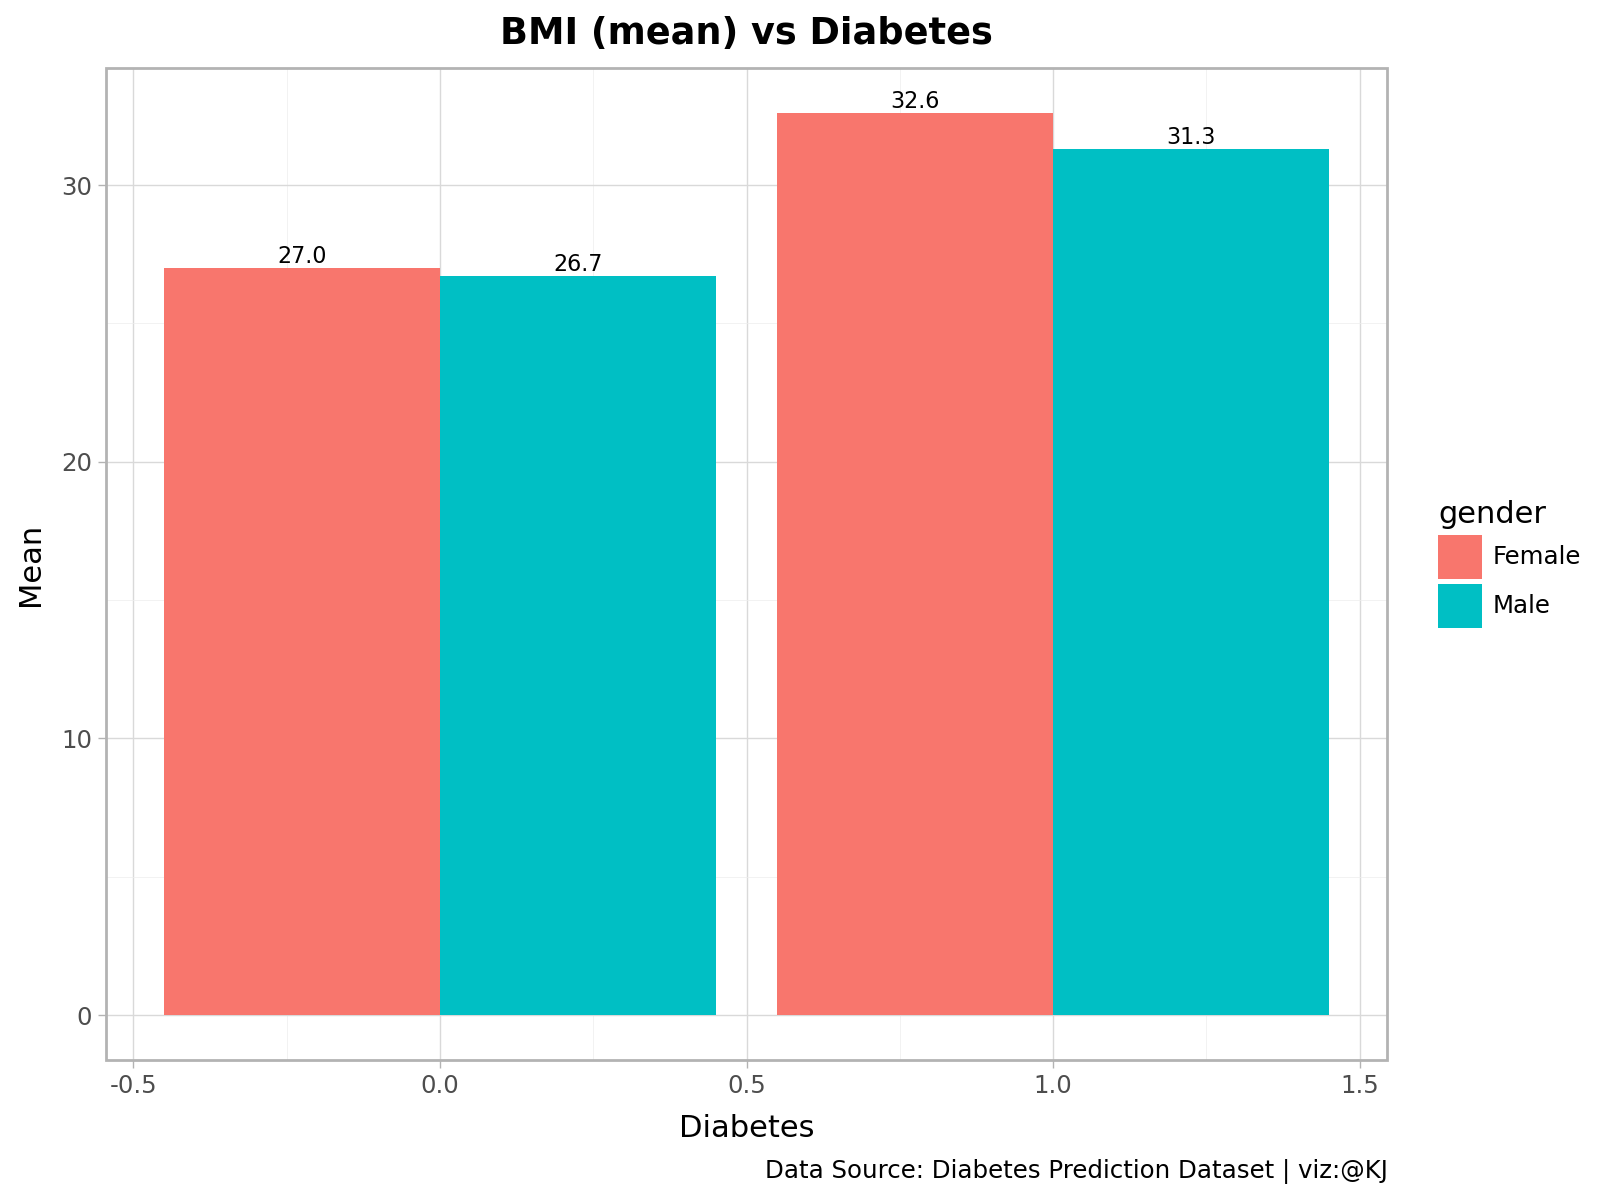

In [30]:
# Let's visualize
(ggplot(bmi_dia, aes("diabetes", "mean", fill="gender"))
+ geom_col(position="dodge")
+ geom_text(
    aes(label="mean"),
    position=position_dodge(width=0.9),
    va='bottom',
    size=8,
    color='black'
)
+ labs(x = "Diabetes", 
       y = "Mean", 
       title = "BMI (mean) vs Diabetes", 
       caption = "Data Source: Diabetes Prediction Dataset | viz:@KJ")
+ theme_light()
+ theme(figure_size=(8,6),
         plot_title = element_text(weight = "bold"))
)

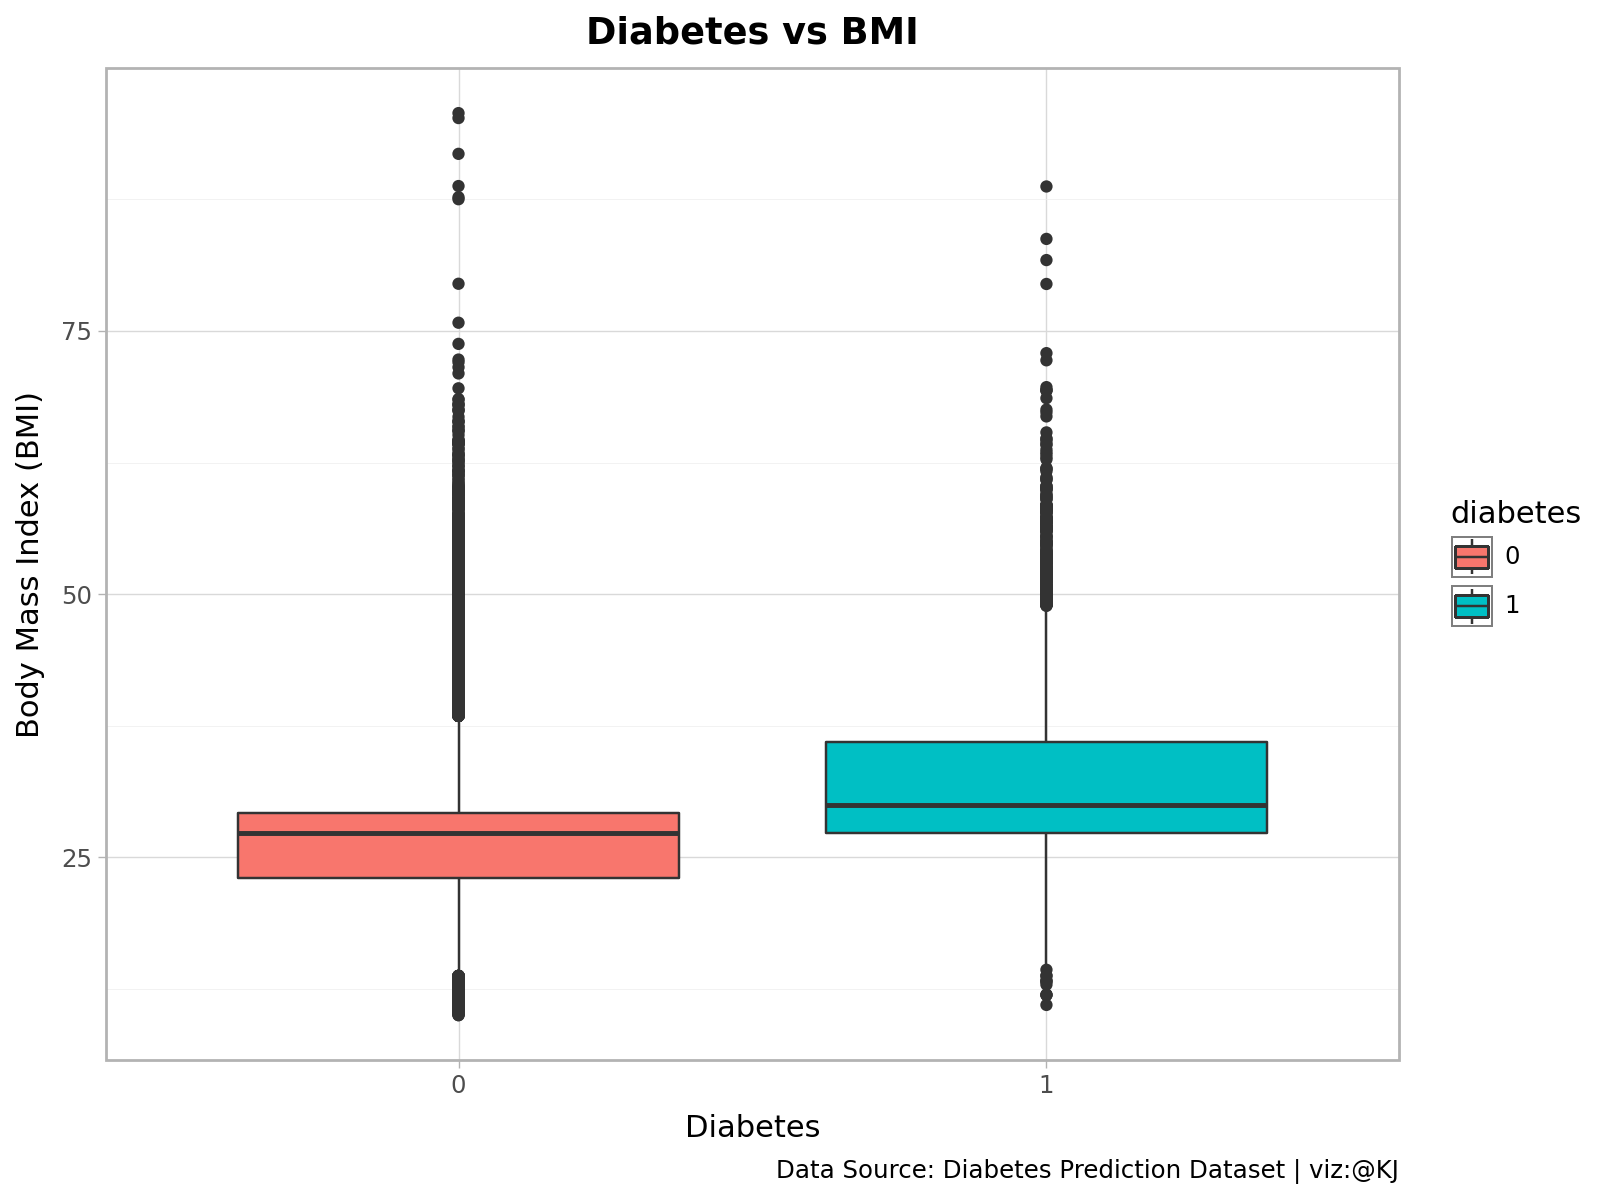

In [31]:
diabetes2 = diabetes_1.copy()
diabetes2["diabetes"] = diabetes2["diabetes"].astype(str)
(ggplot(diabetes2, aes("diabetes", "bmi", fill="diabetes"))
+ geom_boxplot()
+ labs(x = "Diabetes", 
       y = "Body Mass Index (BMI)", 
       title = "Diabetes vs BMI", 
       caption = "Data Source: Diabetes Prediction Dataset | viz:@KJ")
+ theme_light()
+ theme(figure_size=(8,6),
         plot_title = element_text(weight = "bold"))
)

#### **Interpretation**: The two chart reveals that non-diabetic patients has average bmi of **~27kg/m2**, while bmi that is close or above 30 is associated with diabetes.

#### **Differences in the HbA1c_level of Diabetic and Non-Diabetic Patients**

In [32]:
# Aggregate data: Subset HbA1c_level, gender, and diabetes variables from the dataset
hba_dia = diabetes_1.groupby(["diabetes", "gender", "HbA1c_level"])["HbA1c_level"].agg(['mean', 'median']).reset_index()
hba_dia

,diabetes,gender,HbA1c_level,mean,median
0,0,Female,3.5,3.5,3.5
1,0,Female,4.0,4.0,4.0
2,0,Female,4.5,4.5,4.5
3,0,Female,4.8,4.8,4.8
4,0,Female,5.0,5.0,5.0
5,0,Female,5.7,5.7,5.7
6,0,Female,5.8,5.8,5.8
7,0,Female,6.0,6.0,6.0
8,0,Female,6.1,6.1,6.1
9,0,Female,6.2,6.2,6.2


In [33]:
diabetes2.groupby("diabetes")["HbA1c_level"].mean()

diabetes
0    5.396934
1    6.934827
Name: HbA1c_level, dtype: float64

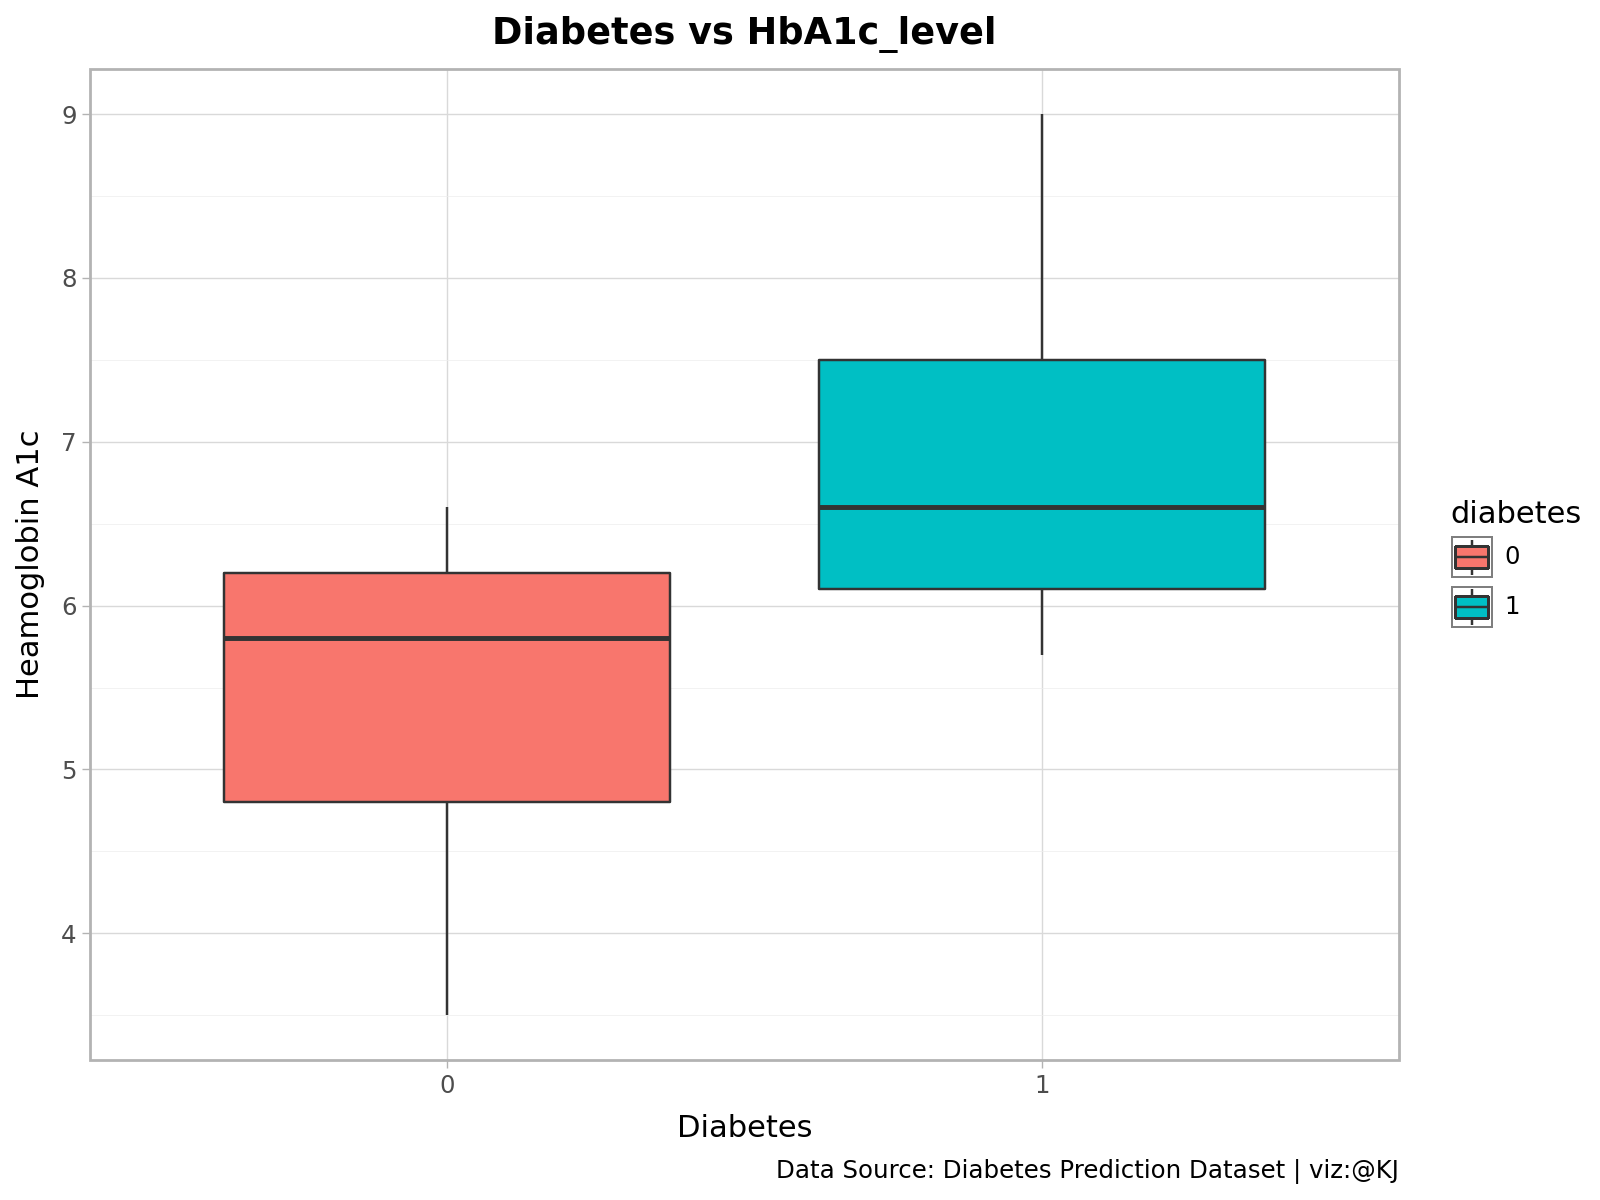

In [34]:
# Let's visualize
(ggplot(diabetes2, aes("diabetes", "HbA1c_level", fill="diabetes"))
+ geom_boxplot()
+ labs(x = "Diabetes", 
       y = "Heamoglobin A1c", 
       title = "Diabetes vs HbA1c_level", 
       caption = "Data Source: Diabetes Prediction Dataset | viz:@KJ")
+ theme_light()
+ theme(figure_size=(8,6),
         plot_title = element_text(weight = "bold"))
)

#### **Interpretation**: The heamoglobin A1c level of non-diabetic patients is very low compared to that of diabetic patients. The average heamoglobin A1c level diabetic and non-diabetic patients are **6.9** and **5.4** respectively

#### **Differences in the Blood Glucose Level of Diabetic and Non-Diabetic Patients**

In [35]:
diabetes_1['blood_glucose_level'].unique()

array([140,  80, 158, 155,  85, 200, 145, 100, 130, 160, 126, 159,  90,
       260, 220, 300, 280, 240])

In [36]:
# Aggregate data: Subset gender and diabetes variables from the dataset, and group it by blood glucose level
glu_dia = diabetes2.groupby(["diabetes", "gender"])['blood_glucose_level'].agg(['mean', 'median']).reset_index()
glu_dia

,diabetes,gender,mean,median
0,0,Female,132.766891,140.0
1,0,Male,132.889430,140.0
2,1,Female,193.837194,160.0
3,1,Male,194.234449,160.0


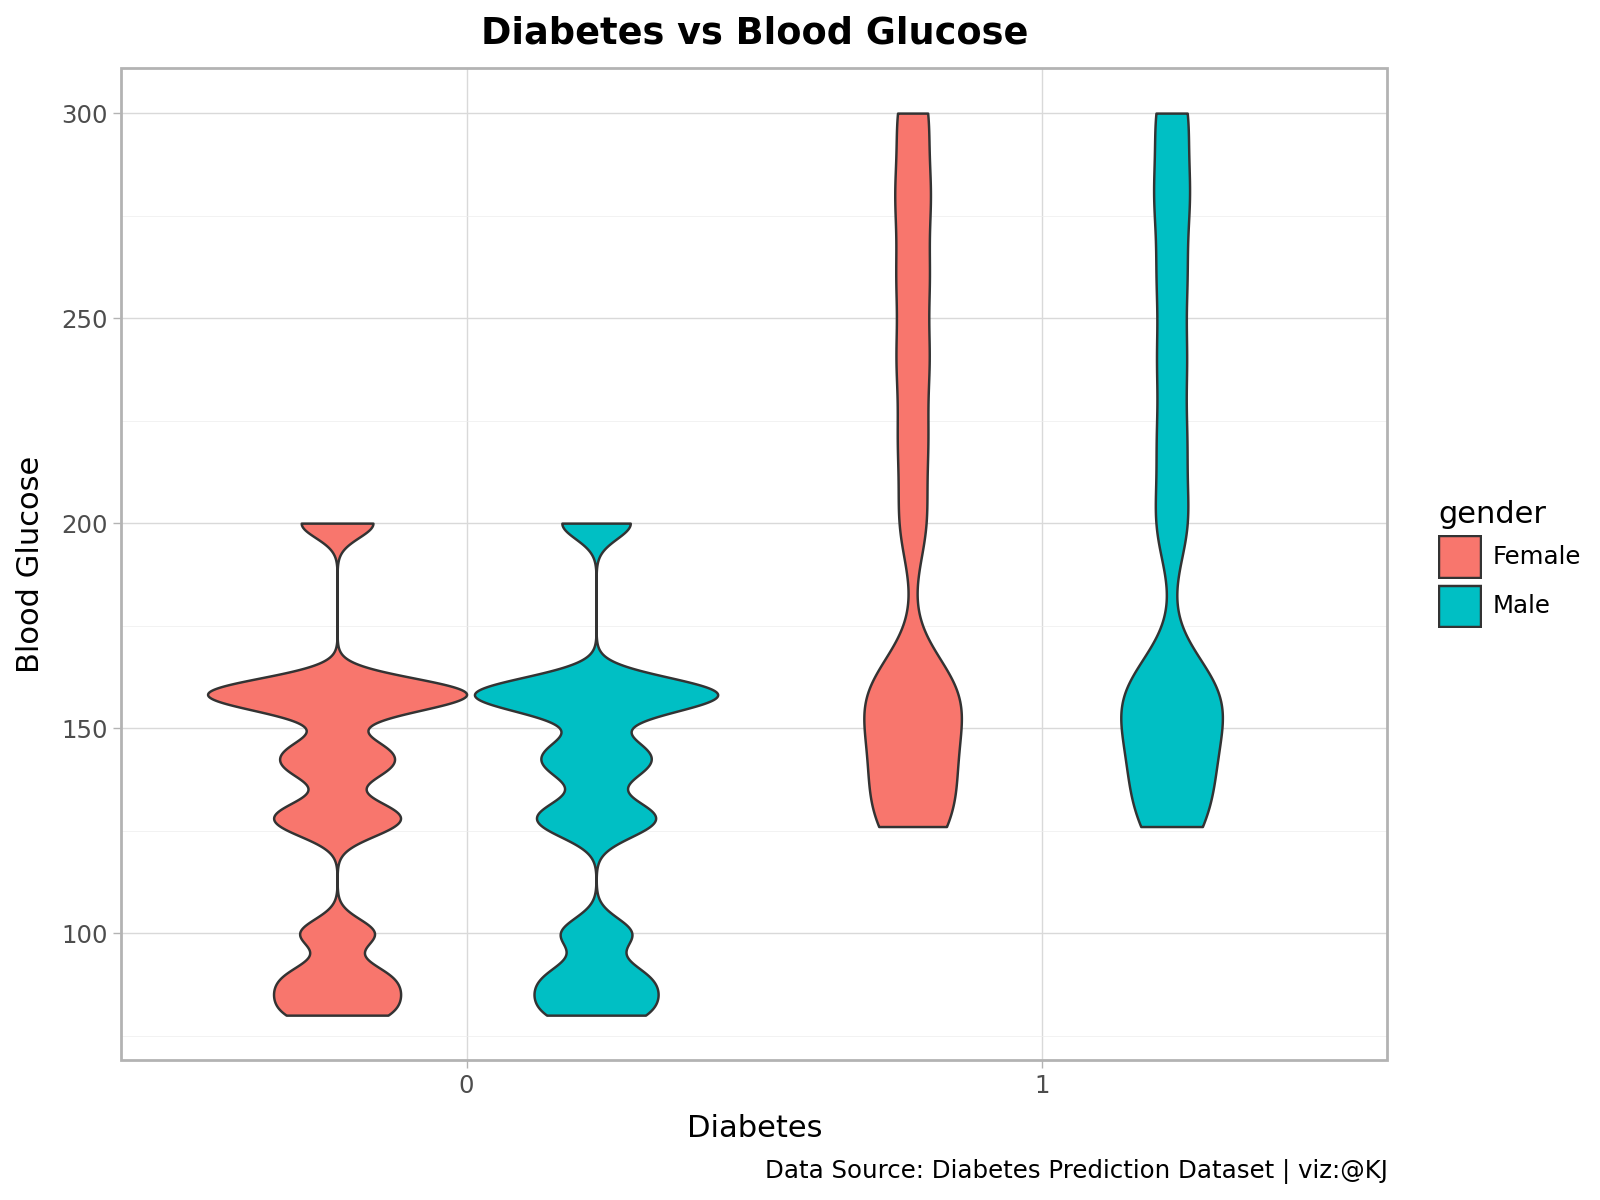

In [37]:
(ggplot(diabetes2, aes("diabetes", "blood_glucose_level", fill="gender"))
+ geom_violin()
+ labs(x = "Diabetes", 
       y = "Blood Glucose", 
       title = "Diabetes vs Blood Glucose", 
       caption = "Data Source: Diabetes Prediction Dataset | viz:@KJ")
+ theme_light()
+ theme(figure_size=(8,6),
         plot_title = element_text(weight = "bold"))
)

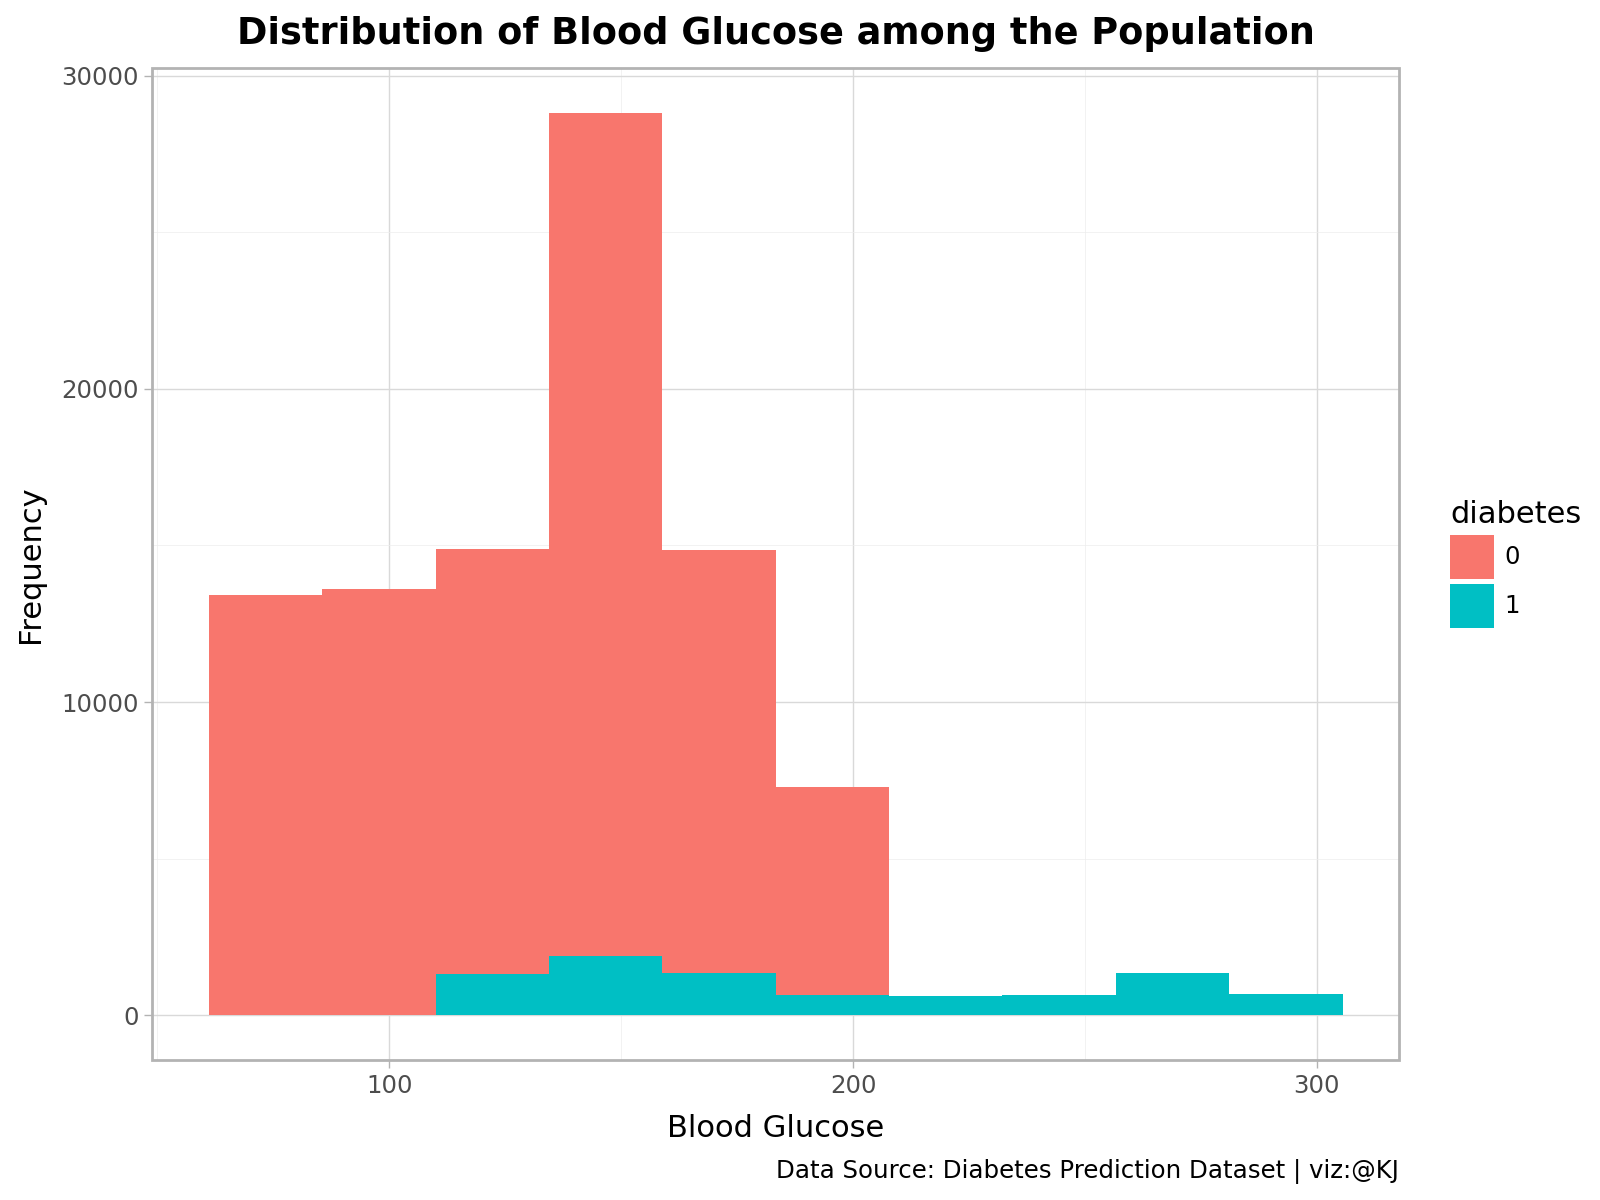

In [38]:
# Let's visualize
(ggplot(diabetes2, aes("blood_glucose_level", fill="diabetes"))
+ geom_histogram(bins=10)
+ labs(x = "Blood Glucose", 
       y = "Frequency", 
       title = "Distribution of Blood Glucose among the Population", 
       caption = "Data Source: Diabetes Prediction Dataset | viz:@KJ")
+ theme_light()
+ theme(figure_size=(8,6),
         plot_title = element_text(weight = "bold"))
)

#### **Interpretation**: The chart shows that both males and females have similar glucose level (the diabetics and non-diabetics). Diabetic patients have higher glucose level which can be over 300. The average glucose for diabetic and non-diabetic patients are approximately 194 and 133 respectively.

#### **Correlation Matrix: Relationship among the Numerical Variables**

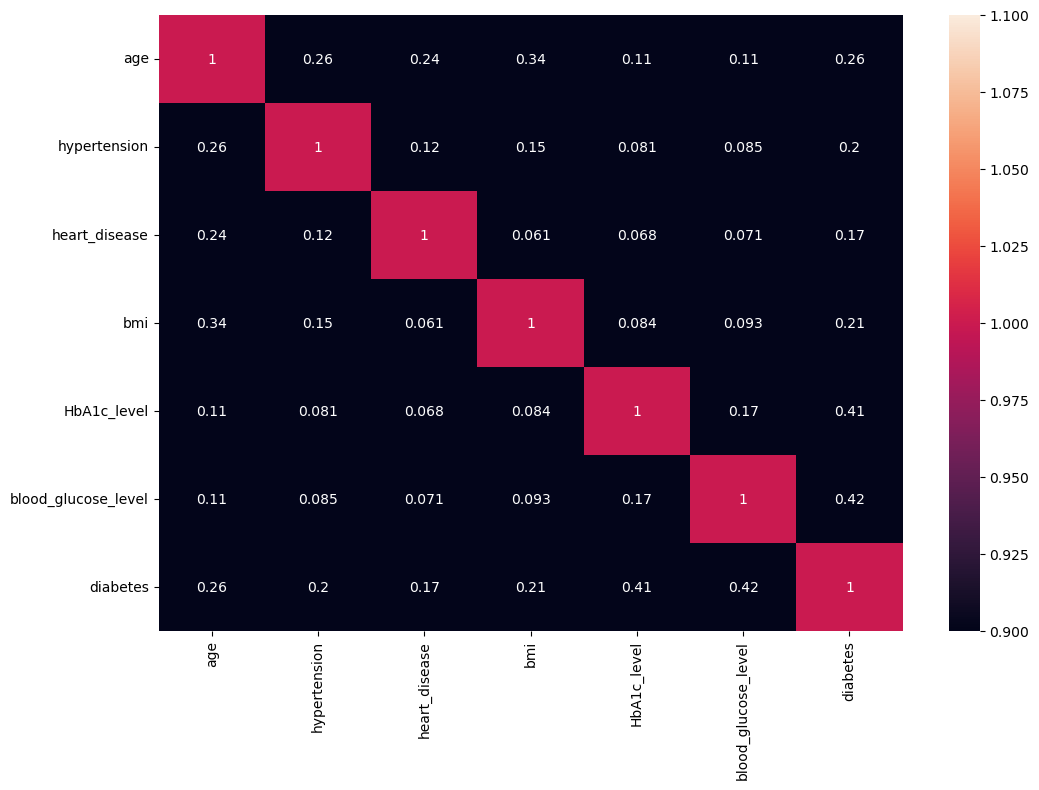

In [39]:
# Let's check the relationship between the variables
import seaborn as sns

plt.figure(figsize = (12, 8))
sns.heatmap(diabetes_1.corr(numeric_only=True), vmin=1, vmax=1, annot=True);

#### **Interpretation**: The heatmap reveals that none of independent variables are highly correlated, hence no multicollinearity, however, they exhibit a normal relationship with the dependent variable (diabetes).

#### **Factors that Contribute to Diabetes**

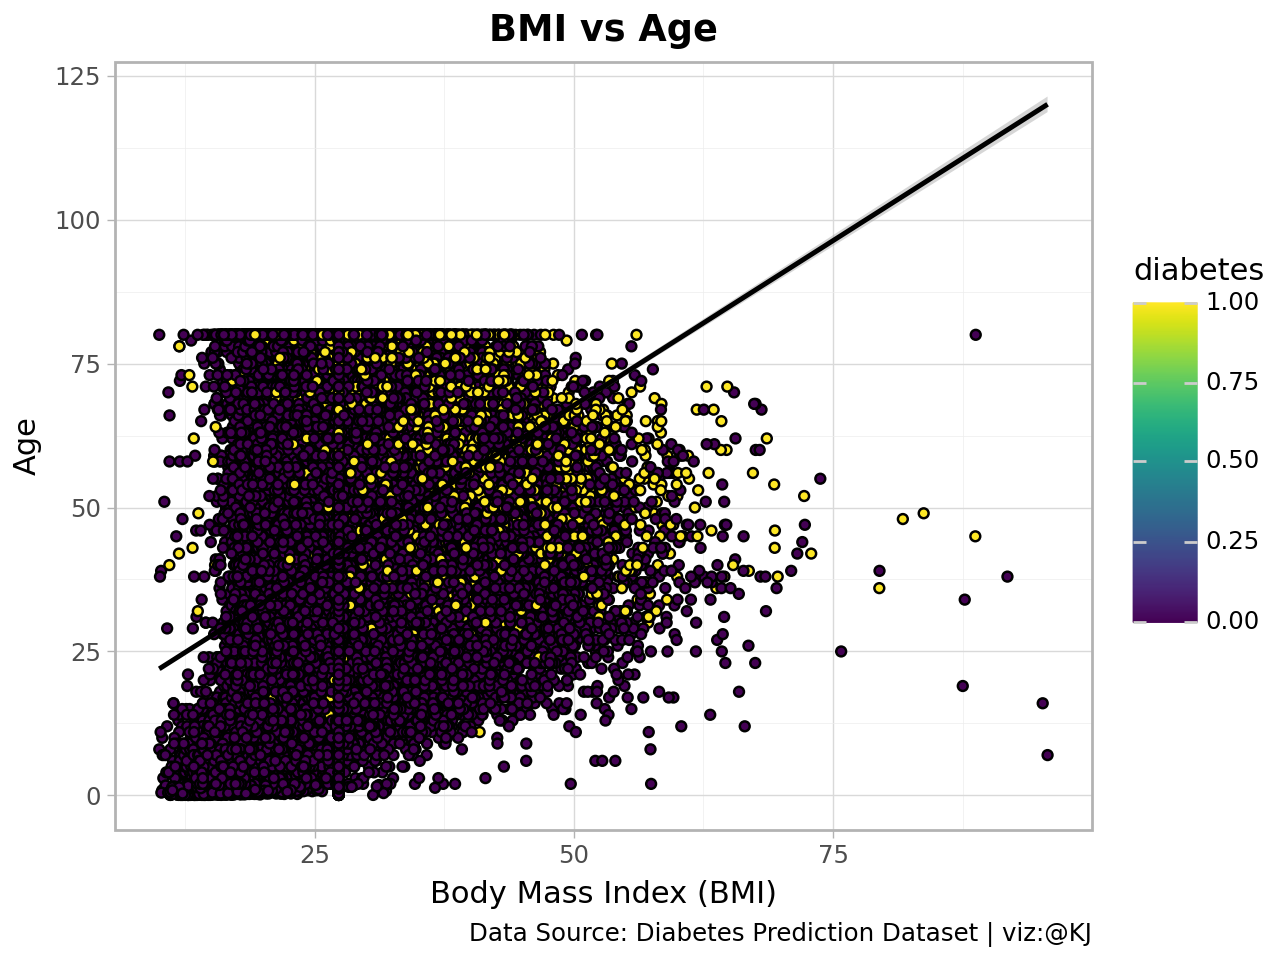

In [40]:
# Plot scatterplot
(ggplot(diabetes_1, aes("bmi", "age", fill="diabetes"))
+ geom_point()
+ geom_smooth()
+ labs(x = "Body Mass Index (BMI)", 
       y = "Age", 
       title = "BMI vs Age", 
       caption = "Data Source: Diabetes Prediction Dataset | viz:@KJ")
+ theme_light()
+ theme(plot_title = element_text(weight = "bold"))
)

#### **Interpretation**:

## **Machine Learning**

#### *In this project, two classification models were trained: Logistic Regression and Random Forest Classifier*

### **Logistic Regression**

In [41]:
# Select the feature and target variables
features = diabetes_1.drop(columns = ["diabetes", "age_group"], axis=1)
target = diabetes_1["diabetes"]

In [42]:
# Splitting data to Training and Testing

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(76902, 8)
(19226, 8)
(76902,)
(19226,)


In [43]:
X_train.columns.tolist()

['gender',
 'age',
 'hypertension',
 'heart_disease',
 'smoking_history',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level']

In [44]:
## Let's separate the numerical and categorical variables and preprocess 
# numerical variables - standardize
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

# binary variables - leave it as it is
binary_cols = ['hypertension', 'heart_disease']

# Categorical - encode
cat_cols = ['gender', 'smoking_history']


In [45]:
# Transform both the numerical and categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("bin", "passthrough", binary_cols)
    ]
)

# Create pipeline
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
    
])

In [46]:
# Let's cross validate
scores = cross_val_score(
    lr_pipeline, 
    X_train,
    y_train,
    cv=5,
    error_score="raise"
)

print(scores.mean())

0.887818327358945


In [47]:
# Fit the model
lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
# Extract the intercept
intercept = lr_pipeline.named_steps['model'].intercept_
intercept_prob = 1 / (1 + np.exp(-intercept))
intercept_prob

array([0.03317709])

### **Interpretation**: An average person in the dataset has about a 3.3% predicted chance of diabetes before considering individual risk factors.

In [49]:
# Extract the coefficient
coef = pd.DataFrame(lr_pipeline.named_steps['model'].coef_.T, lr_pipeline.named_steps['preprocessor'].get_feature_names_out(), ["Coefficient"])
coef

,Coefficient
num__age,1.127379
num__bmi,0.648629
num__HbA1c_level,2.323108
num__blood_glucose_level,1.299874
cat__gender_Male,0.324230
cat__smoking_history_current,0.581298
cat__smoking_history_ever,0.570188
cat__smoking_history_former,0.533730
cat__smoking_history_never,0.485935
cat__smoking_history_not current,0.421650


In [50]:
import numpy as np
coef2 = pd.DataFrame(np.exp(lr_pipeline.named_steps['model'].coef_.T), lr_pipeline.named_steps['preprocessor'].get_feature_names_out(), ["Odds Ratio"])
coef2

,Odds Ratio
num__age,3.087554
num__bmi,1.912916
num__HbA1c_level,10.207351
num__blood_glucose_level,3.668833
cat__gender_Male,1.382966
cat__smoking_history_current,1.788358
cat__smoking_history_ever,1.768600
cat__smoking_history_former,1.705281
cat__smoking_history_never,1.625694
cat__smoking_history_not current,1.524474


#### **Interpretation**: A 1-unit increase in:
Age increases the odds of diabetes by 3.1 times,

BMI -------------------------------by 1.9

HbA1c_level -----------------------by 10.2

Blood glucose ---------------------by 3.67

Heart disease----------------------by 2.18 among others

### **Model Evaluation**

In [51]:
# Make prediction using the train data
y_pred_lr = lr_pipeline.predict(X_train)

# get the classification report
print(classification_report(y_train, y_pred_lr,
                           target_names={"No Diabetes", "Diabetes"}))

# Dictionary version
report1 = classification_report(y_train, y_pred_lr,
                           target_names={"No Diabetes", "Diabetes"}, output_dict=True)

# ROC-AUC Score
y_prob = lr_pipeline.predict_proba(X_train)[:, 1]
roc_auc1 = roc_auc_score(y_train, y_prob)
print(f'ROC-AUC-SCORE: {roc_auc1:.4f}')

              precision    recall  f1-score   support

 No Diabetes       0.99      0.89      0.94     70121
    Diabetes       0.43      0.88      0.58      6781

    accuracy                           0.89     76902
   macro avg       0.71      0.89      0.76     76902
weighted avg       0.94      0.89      0.90     76902

ROC-AUC-SCORE: 0.9627


In [52]:
# Extraction of each metric, to be used in the creation of a dataframe to compare results
log_recall = round(report1["Diabetes"]['recall'], 2)
log_precision = round(report1["Diabetes"]['precision'], 2)
log_f1 = round(report1["Diabetes"]['f1-score'], 2)
log_accuracy = round(report1['accuracy'], 2)
log_roc = round(roc_auc1, 2)

result_df = pd.DataFrame({
   "Models": ["precision", "recall", "fi-score", "accuracy", "roc-auc"],
    "Logistic Regression (Train)": [log_precision, log_recall, log_f1, log_accuracy, log_roc]
})

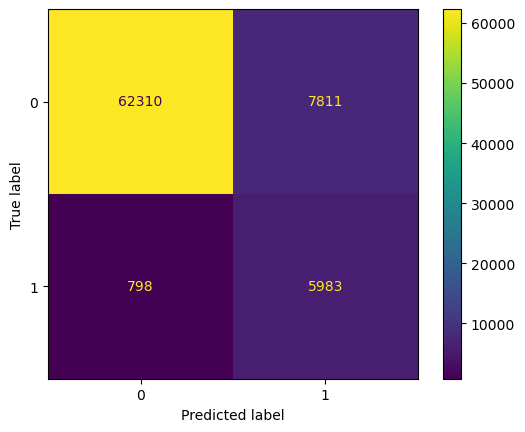

In [53]:
# Visualize the classification
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_lr);

In [54]:
tn1, fp1, fn1, tp1 = confusion_matrix(y_train, y_pred_lr).ravel()

### **Interpretation:** 
The model achieved an overall **accuracy of 89%** and an ROC-AUC score of 0.9627, indicating excellent performance in distinguishing between diabetic and non-diabetic patients. For diabetic patients, the model attained a **recall of 88%**, meaning it correctly identified most actual diabetes cases, while its **precision of 43%** suggests the presence of some false positive predictions. The confusion matrix shows that **5,983** diabetic patients and **62,310** non-diabetic patients were correctly classified, whereas **798** diabetic patients were missed by the model. Overall, the model demonstrates strong predictive capability and is particularly effective as a screening tool, where identifying as many diabetes cases as possible is a priority.

### **Random Forest**

In [55]:
# Transform both the numerical and categorical columns
rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("bin", "passthrough", binary_cols)
    ]
)

# Create pipeline
rf_pipeline = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42))
    
])

In [56]:
# Param grid range to tune the model
paramgrid = {"model__max_depth": list(range(1, 13)),
           "model__n_estimators": list(range(1, 200, 10))}

**This is a cell code changed to markdown because of redoing the gridsearch CV last for almost 1hr**

grid_search = GridSearchCV(
    rf_pipeline,
    paramgrid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

**This is a code cell -- Through the Grid search CV, the max_depth and n_estimators were 11 and 181 respectively**

grid_search.best_params_

In [57]:
# Initiate the model using the best params obtained from grid search cv
rf_pipeline2 = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", criterion='entropy',
                       max_depth=11, n_estimators=181, random_state=42))
    
])


# Fit the model
rf_pipeline2.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


results = pd.DataFrame(grid_search.cv_results_)

# average score for each max_depth
avg_scores = results.groupby("param_model__max_depth")["mean_test_score"].mean()

plt.plot(avg_scores.index, avg_scores.values)
plt.xlabel("max_depth")
plt.ylabel("Mean Test Score")
plt.show()

### **Model Evaluation**

In [58]:
# Make prediction using the train data
y_pred_rf = rf_pipeline2.predict(X_train)

# get the classification report
print(classification_report(y_train, y_pred_rf,
                           target_names={"No Diabetes", "Diabetes"}))

# ROC-AUC Score
y_prob = rf_pipeline2.predict_proba(X_train)[:, 1]
roc_auc2 = roc_auc_score(y_train, y_prob)
print(f'ROC-AUC-SCORE: {roc_auc2:.4f}')

              precision    recall  f1-score   support

 No Diabetes       0.99      0.92      0.95     70121
    Diabetes       0.51      0.91      0.66      6781

    accuracy                           0.92     76902
   macro avg       0.75      0.92      0.81     76902
weighted avg       0.95      0.92      0.93     76902

ROC-AUC-SCORE: 0.9811


In [59]:
# Dictionary version
report2 = classification_report(y_train, y_pred_rf,
                           target_names={"No Diabetes", "Diabetes"}, output_dict=True)

# Extraction of each metric, to be used in the creation of a dataframe to compare results
rf_recall = round(report2["Diabetes"]['recall'], 2)
rf_precision = round(report2["Diabetes"]['precision'], 2)
rf_f1 = round(report2["Diabetes"]['f1-score'], 2)
rf_accuracy = round(report2['accuracy'], 2)
rf_roc = round(roc_auc2, 2)

result_df = pd.DataFrame({
   "Models": ["precision", "recall", "fi-score", "accuracy", "roc-auc"],
    "Logistic Regression (Train)": [log_precision, log_recall, log_f1, log_accuracy, log_roc],
    "Random Forest (Train)": [rf_precision, rf_recall, rf_f1, rf_accuracy, rf_roc]
})

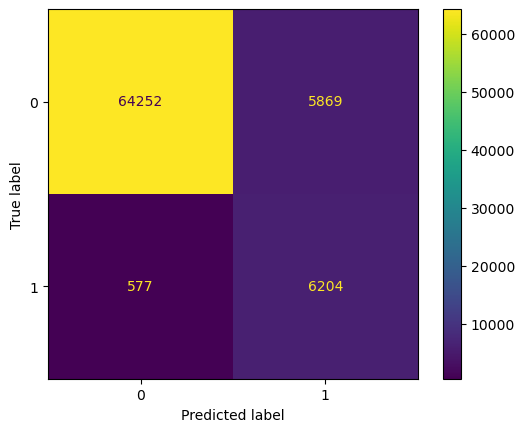

In [60]:
# Visualize the classification
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_rf);

In [61]:
# Extract the value of each result of the confusion matrix
tn2, fp2, fn2, tp2 = confusion_matrix(y_train, y_pred_rf).ravel()

### **Interpretation:**
The model achieved an overall **accuracy of 92%** and an ROC-AUC score of 0.9811, indicating excellent performance in distinguishing between diabetic and non-diabetic patients. For diabetic patients, the model attained a **recall of 91%**, meaning it correctly identified most actual diabetes cases, while its **precision of 51%** suggests the presence of some false positive predictions. The confusion matrix shows that **6,204** diabetic patients and **64,252** non-diabetic patients were correctly classified, whereas **577** diabetic patients were missed by the model. Overall, the model demonstrates strong predictive capability and is particularly effective as a screening tool, where identifying as many diabetes cases as possible is a priority.

### *Based on the classification report and confusion matrix, Random Forest Model performed better than the logistic model*

### **Make Prediction on Testing Data**

In [62]:
# Make prediction using the test data
y_pred_rf2 = rf_pipeline2.predict(X_test)

# get the classification report
print(classification_report(y_test, y_pred_rf2,
                           target_names={"No Diabetes", "Diabetes"}))

# ROC-AUC Score
y_prob = rf_pipeline2.predict_proba(X_test)[:, 1]
roc_auc3 = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC-SCORE: {roc_auc3:.4f}')

              precision    recall  f1-score   support

 No Diabetes       0.99      0.91      0.95     17525
    Diabetes       0.50      0.89      0.64      1701

    accuracy                           0.91     19226
   macro avg       0.74      0.90      0.80     19226
weighted avg       0.95      0.91      0.92     19226

ROC-AUC-SCORE: 0.9747


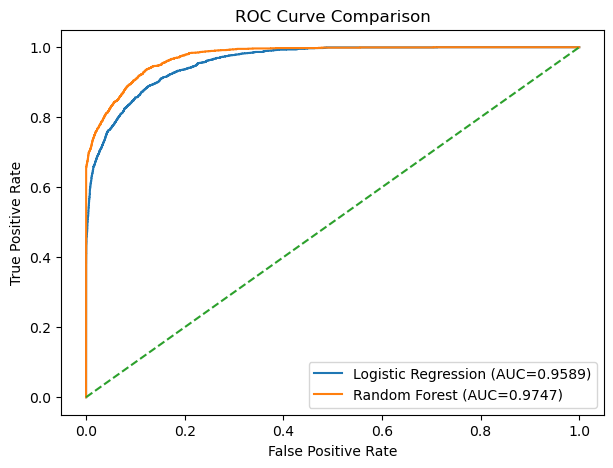

In [65]:
# Visualize the ROC-AUC Score
# Logistic Regression
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

# Random Forest
y_prob_rf = rf_pipeline2.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label= f"Logistic Regression (AUC={auc_lr:.4f})")
plt.plot(fpr_rf, tpr_rf, label= f"Random Forest (AUC={auc_rf:.4f})")
plt.plot([0,1], [0,1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show();

In [ ]:
# Visualize the classification
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf2);

In [ ]:
# Extract the value of each result of the confusion matrix
tn3, fp3, fn3, tp3 = confusion_matrix(y_test, y_pred_rf2).ravel()

### **Interpretation:**
The Random Forest model demonstrates exceptional overall discriminative power on the testing set, achieved through an ROC-AUC score of **0.9747** and an overall accuracy of **91%**. In addressing the severe class imbalance where non-diabetic cases heavily outnumber diabetic cases, the model successfully prioritizes sensitivity, capturing **89%** of positive diabetes cases (recall of 0.89) and minimizing dangerous false negatives to just **185** instances. However, this aggressive screening strategy results in a trade-off for the minority class, as reflected by a lower precision of **0.50** due to **1,508** false positives where non-diabetic patients were flagged as diabetic. Ultimately, for a healthcare application where failing to diagnose a condition carries the highest risk, the model's high recall and strong macro-average metrics present a highly effective and robust predictive tool.

In [ ]:
# Let's extract one tree from the Random Forest Classifier
tree = rf_pipeline2.named_steps['model'].estimators_[0]

plt.figure(figsize=(35,15))
plot_tree(tree, max_depth=3, feature_names = rf_pipeline2.named_steps['preprocessor'].get_feature_names_out(), class_names = True, filled = True, fontsize =12)
plt.show()

plt.savefig("tree.png", dpi=300, bbox_inches='tight')

In [ ]:
# Get the correctly transformed feature names from the preprocessor
feature_names = rf_pipeline2.named_steps['preprocessor'].get_feature_names_out()

# Get the feature importances from the trained random forest model
importances = rf_pipeline2.named_steps['model'].feature_importances_

# Combine them into a DataFrame and sort by importance
feat_imp2 = pd.DataFrame({
    "features": feature_names,
    "importances": importances
}).sort_values(by="importances", ascending=False).reset_index(drop=True)

# Clean up the "num__" and "cat__" prefixes scikit-learn adds automatically
feat_imp2["features"] = feat_imp2["features"].str.replace(r'^(num__|cat__|bin__)', '', regex=True)
feat_imp2

In [ ]:
# Let's visualize the important features
(ggplot(feat_imp2.head(10), aes(x="reorder(features, importances)", y="importances"))
+ geom_col(fill="#2e7d32")
+ geom_text(
    aes(label= round(feat_imp2.head(10)["importances"], 2)),
    position = position_stack(vjust = 0.5),
    size=8,
    color='white'
)
+ coord_flip()
+ theme_minimal()
+ labs(
    title="Top 10 Most Important Features",
    x="Features",
    y="Importance Score"
    )
)

In [ ]:
# Dictionary version
report3 = classification_report(y_test, y_pred_rf2,
                           target_names={"No Diabetes", "Diabetes"}, output_dict=True)
# Extraction of each metric, to be used in the creation of a dataframe to compare results
rft_recall = round(report3["Diabetes"]['recall'], 2)
rft_precision = round(report3["Diabetes"]['precision'], 2)
rft_f1 = round(report3["Diabetes"]['f1-score'], 2)
rft_accuracy = round(report3['accuracy'], 2)
rft_roc = round(roc_auc3, 2)

# Create a dataframe to compare the results of the models
result_df = pd.DataFrame({
   "Models": ["precision", "recall", "fi-score", "accuracy", "roc-auc", "Diabetic patients correctly identified as diabetic", "Non-diabetic patients correctly identified as non-diabetic", "Non-diabetic patients incorrectly identified as diabetic", "Diabetic patients incorrectly identified as non-diabetic"],
    "Logistic Regression (Train)": [log_precision, log_recall, log_f1, log_accuracy, log_roc, tp1, tn1, fp1, fn1],
    "Random Forest (Train)": [rf_precision, rf_recall, rf_f1, rf_accuracy, rf_roc, tp2, tn2, fp2, fn2],
    "Random Forest (Test)": [rft_precision, rft_recall, rft_f1, rft_accuracy, rft_roc, tp3, tn3, fp3, fn3]
})

result_df = result_df.set_index("Models").T
result_df

## **Final Summary:** Predictive Modeling and Risk Assessment for Diabetes Diagnosis

### **Executive Summary**

This study developed and evaluated an optimized machine learning framework to predict diabetes diagnoses using a dataset characterized by a severe class imbalance ($91.2\%$ non-diabetic vs. $8.8\%$ diabetic). By transitioning from a baseline Logistic Regression model to a tuned Random Forest Classifier, predictive accuracy, precision, and discriminative power were significantly improved. Evaluated against an independent testing partition of 19,226 observations, the final Random Forest model achieved an exceptional Area Under the Receiver Operating Characteristic curve (**ROC-AUC = 0.97**) and an overall accuracy of **$91\%$**. Given the critical clinical risk of missing diagnoses, the framework successfully prioritizes sensitivity, capturing **$89\%$** of all true diabetic patients (Recall = 0.89) while minimizing dangerous false negatives to just 185 cases in the test set.

### **Key Empirical Findings and Data Insights**

#### **The Primary Drivers**

The predictive validity of the models relies heavily on direct physiological indicators, which exhibit the strongest linear relationships with the target variable in the correlation analysis:

* **Hemoglobin A1c (HbA1c) Level ($r = 0.41$):** Explored as a premier diagnostic threshold, diabetic individuals exhibited a significantly higher median HbA1c level of **6.9** compared to the non-diabetic cohort median of **5.4**.
* **Blood Glucose Level ($r = 0.42$):** The diabetic population showed a markedly elevated mean glucose concentration of approximately **194 mg/dL**, contrasted with a normal baseline average of **133 mg/dL** in the healthy population. Higher concentrations reaching up to 300 mg/dL served as definitive splitting criteria within the tree-based models.

#### **Socio-Demographic and Comorbidity Associations**

* **Age and Gender Dynamics:** Diabetes prevalence scales dramatically with age, concentrating heavily within the **middle age** and **older adulthood** categories across both genders. Notably, female patients dominated the overall dataset population ($58.4\%$) and showed higher absolute frequencies of diagnosis within older cohorts.
* **Comorbidities:** Cardiovascular and circulatory health showed a strong positive association with diabetes. Specifically, **$28\%$** of hypertensive individuals and **$32.3\%$** of individuals with existing heart disease were diagnosed as diabetic, a stark contrast to the sub-$8\%$ prevalence observed among their healthier counterparts.
* **Lifestyle Factors:** Individuals with a **former smoking history** demonstrated the highest propensity for diabetes among the recorded lifestyle categories, outperforming current smokers and providing an important behavioral indicator for risk stratification.

#### **Comparative Model Evaluation**

To establish the most robust predictive framework, the performance of the baseline Logistic Regression model was compared against the optimized Random Forest architecture across both training and testing datasets:

#### **Summary of Model Performance Metrics**

| Models | Precision | Recall | F1-Score | Accuracy | ROC-AUC | Diabetic patients correctly identified as diabetic | Non-diabetic patients correctly identified as non-diabetic | Non-Diabetic patients incorrectly identified as diabetic | Diabetic patients incorrectly identified as non-diabetic |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **Logistic Regression (Train)** | 0.43 | 0.88 | 0.58 | 0.89 | 0.96 | 5,983.0 | 62,310.0 | 7,811.0 | 798.0 |
| **Random Forest (Train)** | 0.51 | 0.91 | 0.66 | 0.92 | 0.98 | 6,204.0 | 64,252.0 | 5,869.0 | 577.0 |
| **Random Forest (Test)** | 0.50 | 0.89 | 0.64 | 0.91 | 0.97 | 1,516.0 | 16,017.0 | 1,508.0 | 185.0 |

#### **Architectural Performance Breakdown**

1. Moving from Logistic Regression to the Random Forest model on the training data yielded solid improvements across all core metrics. Accuracy increased from **$89\%$ to $92\%$**, precision grew from **$0.43$ to $0.51$**, and recall advanced from **$0.88$ to $0.91$**. This demonstrates that the tree-based ensemble is significantly better at capturing complex, non-linear interactions between clinical features (such as the combined impact of high BMI, age, and blood glucose levels) than a linear baseline.
   
2. The Random Forest model maintained highly stable metrics when transitioning from training to the independent testing data (Accuracy dropping slightly from $92\%$ to $91\%$, and ROC-AUC remaining nearly identical at $0.97$). This minimal generalization error proves that the hyperparameter tuning and cross-validation strategy successfully prevented overfitting, despite allowing the underlying decision trees to grow deep enough to capture minority class patterns.

3. Both architectures reflect deliberate adjustments for class imbalance. By utilizing class weighting, the final testing configuration minimizes critical diagnostic failures, resulting in **only 185 false negatives** (diabetic patients missed). The accompanying trade-off is a lower precision of **$0.50$**, meaning that for every true diabetic patient correctly flagged, approximately one non-diabetic patient is incorrectly flagged (1,508 false positives). In a clinical screening tool, this trade-off is highly acceptable, as a secondary diagnostic follow-up can easily clear false positives, whereas a false negative leaves a patient entirely untreated.


### **Policy and Clinical Recommendations**

* **Tiered Screening Protocols:** Healthcare providers should deploy this Random Forest pipeline as a primary digital triage tool in outpatient clinics. Given its high recall, patients flagged as high-risk can be automatically routed for definitive diagnostic laboratory testing.
  
* **Targeted Public Health Interventions:** Public health campaigns should aggressively target individuals in the "Middle Age" to "Older Adulthood" brackets who present with secondary risk factors like hypertension or a former smoking history, optimizing resource allocation in regions facing constrained healthcare budgets.

* **Preventative Biometric Monitoring:** Because HbA1c and blood glucose levels display the tightest correlation with diagnosis, preventative health policies should incentivize routine, automated screening of these two metrics for adults over 40 to catch pre-diabetic trajectories before clinical onset.